In [ ]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install tmu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 kB 34.2 MB/s eta 0:00:00


In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 27.4 MB/s eta 0:00:00


In [ ]:
!pip install pyTsetlinMachineParallel -q

  Preparing metadata (setup.py) ... done


In [ ]:
!py -m pip install shap -q

/bin/bash: line 1: py: command not found


In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# filepath = "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank.py"

# with open(filepath, "r") as f:
#     content = f.read()

# with open(filepath, "w") as f:
#     f.write(content.replace("np.uint32(~0)", "np.iinfo(np.uint32).max"))

# print("Done")

Done


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/macro/combined_macro_data.csv", parse_dates=["date"])

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from tmu.models.regression.vanilla_regressor import TMRegressor
from pyTsetlinMachineParallel.tm import RegressionTsetlinMachine
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error,mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
from sklearn.inspection import permutation_importance
import shap
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
import lime
import lime.lime_tabular

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

ERROR:tmu.clause_bank.clause_bank_cuda:No module named 'pycuda'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'


### pipeline

In [ ]:
PARAM_GRIDS = {
    'RF': {
        'model__n_estimators':      [300, 500, 800],
        'model__max_depth':         [3, 5, 7, None],
        'model__min_samples_leaf':  [2, 3, 5],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features':      ['sqrt', 0.5, 0.7],
    },
    'GB': {
        'model__n_estimators':   [200, 300, 500],
        'model__learning_rate':  [0.01, 0.03, 0.05, 0.1],
        'model__max_depth':      [2, 3, 4],
        'model__subsample':      [0.6, 0.7, 0.8],
        'model__min_samples_leaf': [2, 3, 5],
    },
    'XGB': {
        'model__n_estimators':     [300, 500, 800],
        'model__learning_rate':    [0.01, 0.03, 0.05],
        'model__max_depth':        [2, 3, 4],
        'model__subsample':        [0.6, 0.7, 0.8],
        'model__colsample_bytree': [0.6, 0.7, 0.8],
        'model__reg_alpha':        [0.0, 0.1, 0.5, 1.0],
        'model__reg_lambda':       [0.5, 1.0, 2.0],
        'model__min_child_weight': [1, 3, 5],
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 10, 15],
        'model__weights':     ['uniform', 'distance'],
        'model__metric':      ['euclidean', 'manhattan', 'minkowski'],
        'model__leaf_size':   [20, 30, 40],
    },
    'SVR': {
        'model__C':       [0.1, 1.0, 10.0, 50.0, 100.0],
        'model__epsilon': [0.001, 0.01, 0.05, 0.1],
        'model__gamma':   ['scale', 'auto', 0.01, 0.1],
        'model__kernel':  ['rbf', 'linear'],
    },
    'bayes': {
        'model__alpha_1':  [1e-7, 1e-6, 1e-5],
        'model__alpha_2':  [1e-7, 1e-6, 1e-5],
        'model__lambda_1': [1e-7, 1e-6, 1e-5],
        'model__lambda_2': [1e-7, 1e-6, 1e-5],
        'model__max_iter': [300, 500, 1000],
    },
    'catboost': {
        'model__iterations':    [300, 500, 800],
        'model__learning_rate': [0.01, 0.03, 0.05],
        'model__depth':         [3, 4, 5, 6],
        'model__l2_leaf_reg':   [1.0, 3.0, 5.0, 10.0],
        'model__subsample':     [0.6, 0.7, 0.8],
    },
}

In [ ]:
BASE_MODELS = {
    'RF':       RandomForestRegressor(random_state=42, n_jobs=-1),
    'GB':       GradientBoostingRegressor(random_state=42),
    'XGB':      XGBRegressor(random_state=42, objective='reg:squarederror',
                             tree_method='hist', verbosity=0),
    'KNN':      KNeighborsRegressor(),
    'SVR':      SVR(),
    'bayes':    BayesianRidge(),
    'catboost': CatBoostRegressor(random_state=42, verbose=0),
}

In [ ]:
def tune_model(model_name, pipeline_steps_before_model,
               X_train, y_train, n_iter=30, cv_splits=5):
    steps = pipeline_steps_before_model + [('model', BASE_MODELS[model_name])]
    pipe  = Pipeline(steps)

    tscv = TimeSeriesSplit(n_splits=cv_splits)

    search = RandomizedSearchCV(
        estimator          = pipe,
        param_distributions= PARAM_GRIDS[model_name],
        n_iter             = n_iter,
        cv                 = tscv,
        scoring            = 'r2',
        random_state       = 42,
        n_jobs             = -1,
        refit              = True
    )
    search.fit(X_train, y_train)

    print(f"  Best CV R²: {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")

    return search.best_estimator_

In [ ]:

def standard_importance(fitted_model, pipeline, X_train, y_train, feature_names):
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=10, random_state=42)
        importances = perm.importances_mean
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)



In [ ]:
def shap_importance(fitted_model, X_train, feature_names):
    X_train_df  = pd.DataFrame(X_train, columns=feature_names)
    tree_models = (RandomForestRegressor, GradientBoostingRegressor,
                   XGBRegressor, CatBoostRegressor)
    if isinstance(fitted_model, tree_models):
        explainer   = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_train_df)
    else:
        explainer   = shap.KernelExplainer(
            fitted_model.predict, shap.sample(X_train_df, 50))
        shap_values = explainer.shap_values(X_train_df)
    importances = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True), shap_values, X_train_df

In [ ]:

def permutation_importance_ranked(pipeline, X_train, y_train, feature_names):
    perm = permutation_importance(pipeline, X_train, y_train,
                                  n_repeats=20, random_state=42)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)



In [ ]:
def plot_macro_bar(fi_df, title):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_permutation(fi_df, model_name):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    top = fi_df.head(20)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            xerr=top['std'][::-1] if 'std' in top.columns else None,
            color='mediumseagreen', capsize=3)
    ax.set_title(f"Permutation Importance — Top 20\n({model_name})")
    ax.set_xlabel("Mean accuracy decrease (±std)")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_shap(shap_values, X_train_df, model_name):
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=False)
    plt.title(f"SHAP — Mean |SHAP| ({model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_train_df, show=False)
    plt.title(f"SHAP — Direction & Magnitude ({model_name})")
    plt.tight_layout()
    plt.show()


In [ ]:


def lime_importance(fitted_model, X_train, X_test, feature_names, model_name):
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data   = X_train,
        feature_names   = feature_names,
        mode            = 'regression',
        discretize_continuous = True,
        random_state    = 42
    )

    all_weights = []
    for i in range(len(X_test)):
        exp         = explainer.explain_instance(
            X_test[i],
            fitted_model.predict,
            num_features = len(feature_names),
            num_samples  = 500
        )
        weights_dict = dict(exp.as_list())
        row          = {f: 0.0 for f in feature_names}
        for key, val in weights_dict.items():
            for fname in feature_names:
                if fname in key:
                    row[fname] = val
                    break
        all_weights.append(row)

    lime_df   = pd.DataFrame(all_weights)

    fi_lime = pd.DataFrame({
        'feature':        feature_names,
        'importance':     lime_df.abs().mean(),
        'mean_effect':    lime_df.mean(),
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(fi_lime.head(20)) * 0.35)))

    top = fi_lime.head(20)
    axes[0].barh(top['feature'][::-1], top['importance'][::-1], color='mediumpurple')
    axes[0].set_title(f"LIME — Mean |Weight| ({model_name})")
    axes[0].set_xlabel("Mean Absolute LIME Weight")
    axes[0].grid(True, alpha=0.3)

    colors = ['tomato' if v < 0 else 'steelblue' for v in top['mean_effect'][::-1]]
    axes[1].barh(top['feature'][::-1], top['mean_effect'][::-1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"LIME — Direction of Effect ({model_name}) Blue=increases CPI, Red=decreases CPI")
    axes[1].set_xlabel("Mean Signed LIME Weight")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LIME Feature Importance — {model_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return fi_lime

In [ ]:
def compute_and_plot_importance(strategy, fitted_model, pipeline,
                                X_train, y_train, feature_names,
                                macro_vars, model_name, use_macro,
                                X_test=None):
    run_standard    = strategy in ('standard',    'all')
    run_shap        = strategy in ('shap',        'all')
    run_permutation = strategy in ('permutation', 'all')
    run_lime        = strategy in ('lime',        'all')

    fi_standard = fi_shap = fi_perm = fi_lime = None

    if run_standard:
        fi_standard = standard_importance(fitted_model, pipeline,
                                          X_train, y_train, feature_names)
        macro_fi    = fi_standard[fi_standard['feature'].apply(
                          lambda f: any(f == m or f.startswith(m + "_")
                                        for m in macro_vars))].reset_index(drop=True)
        other_fi    = fi_standard[~fi_standard.index.isin(macro_fi.index)].reset_index(drop=True)
        if use_macro and not macro_fi.empty:
            plot_macro_bar(macro_fi, f"Standard Importance — Macro\n({model_name})")
        if not other_fi.empty:
            plot_macro_bar(other_fi, f"Standard Importance — Other\n({model_name})")

    if run_shap:
        fi_shap, shap_values, X_train_df = shap_importance(fitted_model, X_train, feature_names)
        plot_shap(shap_values, X_train_df, model_name)

    if run_permutation:
        fi_perm = permutation_importance_ranked(pipeline, X_train, y_train, feature_names)
        plot_permutation(fi_perm, model_name)

    if run_lime:
        if X_test is not None:
            fi_lime = lime_importance(fitted_model, X_train, X_test,
                                      feature_names, model_name)
        else:
            print("LIME skipped — X_test not passed to compute_and_plot_importance")

    return fi_standard, fi_shap, fi_perm, fi_lime


In [ ]:
def run_arima(y_train, y_test, test_dates, X_train=None, X_test=None, use_macro=False):
    if X_train is not None:
          lag_cols = [c for c in X_train.columns if c.endswith('_lag1')]
          X_train  = X_train[lag_cols] if len(lag_cols) else None
          X_test   = X_test[lag_cols]  if len(lag_cols) else None

    exog_train = X_train if use_macro and X_train is not None else None
    exog_test  = X_test  if use_macro and X_test  is not None else None

    best_result = None
    best_aic    = np.inf

    for p in [1, 2, 4]:
        for d in [0, 1]:
            for q in [0, 1]:
                try:
                    m = SARIMAX(y_train, exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(1, 0, 0, 4),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic    = m.aic
                        best_result = m
                except Exception:
                    continue

    predictions = np.array(best_result.forecast(steps=len(y_test), exog=exog_test))
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_cpiret":    y_test.values,
        "predicted_cpiret": predictions
    })

    print(f"\n{'='*65}")
    print(f"ARIMA — Best AIC: {best_aic:.2f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual_cpiret'] - row['predicted_cpiret'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_cpiret']:>12.6f} {row['predicted_cpiret']:>12.6f} {error:>12.6f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAE:':>45}  {mae:>12.4f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")
    print("\nNote: ARIMA coefficients:")
    print(best_result.params)

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["actual_cpiret"],    marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["predicted_cpiret"], marker="o", label="Predicted", linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("cpiret")
    ax.set_title(f"CPI Prediction — ARIMA\n(R²={r2:.3f}  RMSE={rmse:.6f}  MAPE={mape:.1f}%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2


In [ ]:
def run_tsetlin(X_train, X_test, y_train, y_test, test_dates,
                feature_names, importance_strategy,
                n_bins=10, epochs=30, tune=True, n_trials=30,
                use_macro=True):

    if not use_macro:
        drop_cols = [c for c in X_train.columns
                     if any(c == m or c.startswith(f"{m}_") for m in macro_vars)]
        X_train = X_train.drop(columns=drop_cols, errors='ignore')
        X_test  = X_test.drop(columns=drop_cols, errors='ignore')
        feature_names = X_train.columns.tolist()

    raw_macro_in_X = [c for c in X_train.columns if c in macro_vars]
    X_train = X_train.drop(columns=raw_macro_in_X, errors='ignore')
    X_test  = X_test.drop(columns=raw_macro_in_X, errors='ignore')
    feature_names = X_train.columns.tolist()

    # Keep X_test as DataFrame for recursive index lookups
    X_test_df = X_test.copy()

    X_train = X_train.values
    X_test  = X_test_df.values

    scaler  = RobustScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    TOP_K_SEL = min(15, X_tr_sc.shape[1])
    selector  = SelectKBest(score_func=f_regression, k=TOP_K_SEL)
    X_tr_sel  = selector.fit_transform(X_tr_sc, y_train)
    selected_features = np.array(feature_names)[selector.get_support()].tolist()

    # Column indices (in unselected scaled space) for cpiret lag/roll features
    # needed to propagate recursive predictions
    all_feat   = list(X_test_df.columns)
    lag_cols   = {lag: f"cpiret_lag{lag}" for lag in [1, 2, 4]}
    roll_cols  = {w:   f"cpiret_roll{w}"  for w   in [2, 4]}
    lag_idx    = {lag: all_feat.index(col) for lag, col in lag_cols.items()
                  if col in all_feat}
    roll_idx   = {w:   all_feat.index(col) for w,   col in roll_cols.items()
                  if col in all_feat}

    base_model = linear_model.BayesianRidge(max_iter=500)
    base_model.fit(X_tr_sel, y_train)
    train_pred = base_model.predict(X_tr_sel)

    X_te_sc_rec = X_te_sc.copy()          # mutable copy for lag propagation
    test_pred   = []

    for i in range(len(X_te_sc_rec)):
        X_te_sel_i = selector.transform(X_te_sc_rec[[i]])
        pred_i     = base_model.predict(X_te_sel_i)[0]
        test_pred.append(pred_i)

        # Write predicted cpiret into future rows' lag columns
        for lag, col_i in lag_idx.items():
            future = i + lag
            if future < len(X_te_sc_rec):
                X_te_sc_rec[future, col_i] = pred_i

        # Recompute rolling means from predictions so far
        for w, col_i in roll_idx.items():
            future = i + 1
            if future < len(X_te_sc_rec):
                window = test_pred[-w:] if len(test_pred) >= w else test_pred
                X_te_sc_rec[future, col_i] = float(np.mean(window))

    test_pred   = np.array(test_pred, dtype=np.float32)
    X_te_sel_rec = selector.transform(X_te_sc_rec)   # final selected features
    base_r2      = r2_score(y_test, test_pred)

    y_train_arr = np.asarray(y_train, dtype=np.float32)
    y_test_arr  = np.asarray(y_test,  dtype=np.float32)
    residuals   = y_train_arr - train_pred.astype(np.float32)
    resid_mean  = float(np.mean(residuals))
    resid_std   = float(np.std(residuals)) if np.std(residuals) > 1e-6 else 1.0
    resid_sc    = ((residuals - resid_mean) / resid_std).astype(np.float32)

    booleaniser = KBinsDiscretizer(n_bins=n_bins, encode='ordinal',
                                   strategy='quantile')
    X_tr_bits = booleaniser.fit_transform(X_tr_sel).astype(np.uint32)
    X_te_bits = booleaniser.transform(X_te_sel_rec).astype(np.uint32)

    if tune:
        split      = int(0.8 * len(X_tr_bits))
        X_opt_tr   = X_tr_bits[:split];  y_opt_tr  = resid_sc[:split]
        X_opt_val  = X_tr_bits[split:];  y_full_val = y_train_arr[split:]
        base_val   = train_pred[split:].astype(np.float32)

        def objective(trial):
            clauses = trial.suggest_int("number_of_clauses", 50, 500)
            T       = trial.suggest_int("T", 10, 100)
            s       = trial.suggest_float("s", 1.2, 5.0)
            tm = TMRegressor(number_of_clauses=clauses, T=T, s=s,
                             seed=42, weighted_clauses=True)
            for _ in range(30):
                tm.fit(X=X_opt_tr, Y=y_opt_tr)
            resid_pred = tm.predict(X_opt_val).astype(np.float32)
            y_pred_val = base_val + (resid_pred * resid_std + resid_mean)
            return math.sqrt(mean_squared_error(y_full_val, y_pred_val))

        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best = study.best_params
    else:
        best = {"number_of_clauses": 200, "T": 50, "s": 2.5}

    tm = TMRegressor(**best, seed=42, weighted_clauses=True)
    for _ in range(epochs):
        tm.fit(X=X_tr_bits, Y=resid_sc)

    resid_pred_te = tm.predict(X_te_bits).astype(np.float32)
    clip_val      = float(np.abs(residuals).max()) * 2.0
    tm_correction = np.clip(resid_pred_te * resid_std + resid_mean,
                            -clip_val, clip_val)
    y_pred = test_pred + 0.2 * tm_correction

    resid_pred_tr = tm.predict(X_tr_bits).astype(np.float32)
    y_pred_tr     = (train_pred.astype(np.float32)
                     + np.clip(resid_pred_tr * resid_std + resid_mean,
                               -clip_val, clip_val))
    calibrator = LinearRegression()
    calibrator.fit(y_pred_tr.reshape(-1, 1), y_train_arr)
    y_pred = calibrator.predict(y_pred.reshape(-1, 1)).ravel().astype(np.float32)

    rmse = math.sqrt(mean_squared_error(y_test_arr, y_pred))
    mae  = mean_absolute_error(y_test_arr, y_pred)
    mape = mean_absolute_percentage_error(y_test_arr, y_pred) * 100
    r2   = r2_score(y_test_arr, y_pred)

    results = pd.DataFrame({
        "date":            test_dates.values,
        "actual":          y_test_arr,
        "predicted":       y_pred,
        "base_prediction": test_pred
    })

    fi_perm = None
    try:
        perm = permutation_importance(
            base_model, X_te_sel_rec, y_test,
            n_repeats=10, random_state=42,
            scoring='neg_root_mean_squared_error'
        )
        fi_perm = (pd.DataFrame({
                       "feature":    selected_features,
                       "importance": perm.importances_mean})
                   .sort_values("importance", ascending=False))
    except Exception as e:
        print(f"Permutation importance failed: {e}")

    print(f"\n{'='*65}")
    print("Bayes + Tsetlin Residual Corrector")
    print(f"Base R²: {base_r2:.4f}  →  Final R²: {r2:.4f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual'] - row['predicted'])
        print(f"{str(row['date'])[:10]:<15} {row['actual']:>12.2f} "
              f"{row['predicted']:>12.2f} {error:>12.2f}")
    print(f"{'-'*65}")
    print(f"{'MAE:':>45} {mae:.4f}")
    print(f"{'RMSE:':>45} {rmse:.4f}")
    print(f"{'MAPE (%):':>45} {mape:.2f}")
    print(f"{'R²:':>45} {r2:.4f}")
    print(f"{'='*65}")

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["actual"],          marker="o", label="Actual",          linewidth=2)
    ax.plot(x, results["base_prediction"], marker="s", label="Base Bayesian",   linewidth=1.5,
            linestyle="--", alpha=0.6)
    ax.plot(x, results["predicted"],       marker="o", label="TM Corrected",    linewidth=2)
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("CPI Growth (%)")
    ax.set_title(f"CPI Growth Forecast\n"
                 f"Base R²={base_r2:.3f} → Final R²={r2:.3f} | RMSE={rmse:.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2, fi_perm

In [ ]:
macro_vars = [
        "wti_price","fedfunds","nfci","anfci","nfci_risk","nfci_credit",
        "nfci_leverage","nfci_nonfinancial_leverage","gdp","gdp_growth","ppi",
        "trade_balance","unrate","usd_index"
    ]

def CPI_prediction(data, use_macro, model,
                   use_scaling, test_quarters=8,
                   use_lags=True, use_rolling=True,
                   feature_selection=False, n_features=15,
                   importance_strategy='standard',
                   tune=True, n_iter=30, cv_splits=5):

    df = data.copy().sort_values("date").reset_index(drop=True)

    if use_lags:
        for lag in [1, 2, 4]:
            df[f"cpiret_lag{lag}"] = df["cpiret"].shift(lag)
        for col in macro_vars:
            if col in df.columns:
                df[f"{col}_lag1"] = df[col].shift(1)

    if use_rolling:
        for w in [2, 4]:
            df[f"cpiret_roll{w}"] = df["cpiret"].shift(1).rolling(w).mean()

    df = df.dropna().reset_index(drop=True)
    dates = df["date"]

    X = df.drop(columns=["cpiret", "date"])
    X = X.drop(columns=[c for c in macro_vars if c in X.columns], errors='ignore')
    y = df["cpiret"]

    if not use_macro:
        drop_cols = macro_vars + [c for c in X.columns
                                  if any(c.startswith(m) for m in macro_vars)]
        X = X.drop(columns=drop_cols, errors="ignore")

    X_train       = X.iloc[:-test_quarters]
    X_test        = X.iloc[-test_quarters:]
    y_train       = y.iloc[:-test_quarters]
    y_test        = y.iloc[-test_quarters:]
    test_dates    = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()

    print(f"Total: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_names)}")

    if model == 'arima':
        return run_arima(y_train, y_test, test_dates,
                         X_train if use_macro else None,
                         X_test  if use_macro else None,
                         use_macro)

    if model == 'tsetlin':
        return run_tsetlin(X_train, X_test,
                       y_train, y_test, test_dates,
                       feature_names, importance_strategy,
                       tune=tune, n_trials=n_iter,
                       use_macro=use_macro)

    pre_steps = []
    if use_scaling:
        pre_steps.append(('scaler', RobustScaler()))
    if feature_selection:
        pre_steps.append(('selector', SelectKBest(f_regression,
                                                   k=min(n_features, X.shape[1]))))

    if tune and model in PARAM_GRIDS:
        print(f"\nTuning {model} with TimeSeriesSplit (n_iter={n_iter}, cv={cv_splits})...")
        best_pipeline = tune_model(model, pre_steps, X_train, y_train,
                                   n_iter=n_iter, cv_splits=cv_splits)
    else:
        default_models = {
            'RF':       RandomForestRegressor(n_estimators=500, max_depth=5,
                            min_samples_leaf=3, random_state=42, n_jobs=-1),
            'GB':       GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                            max_depth=3, min_samples_leaf=3, subsample=0.8, random_state=42),
            'XGB':      XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                            subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1,
                            reg_lambda=1.0, random_state=42, objective='reg:squarederror',
                            verbosity=0),
            'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
            'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
            'bayes':    BayesianRidge(max_iter=500),
            'catboost': CatBoostRegressor(iterations=500, learning_rate=0.03, depth=4,
                            l2_leaf_reg=5.0, random_state=42, verbose=0),
        }
        steps = pre_steps + [('model', default_models[model])]
        best_pipeline = Pipeline(steps)
        best_pipeline.fit(X_train, y_train)


    predictions = []
    X_test_recursive = X_test.copy()

    for i in range(len(X_test)):
      row = X_test_recursive.iloc[[i]]
      pred = best_pipeline.predict(row)[0]
      predictions.append(pred)

      # Propagate prediction into subsequent rows as lagged cpiret features
      for lag in [1, 2, 4]:
          future_idx = i + lag
          if future_idx < len(X_test_recursive):
              col = f"cpiret_lag{lag}"
              if col in X_test_recursive.columns:
                  X_test_recursive.iloc[future_idx,
                      X_test_recursive.columns.get_loc(col)] = pred

      # Update rolling means using predicted value
      for w in [2, 4]:
          col = f"cpiret_roll{w}"
          if col in X_test_recursive.columns:
              # Recompute rolling mean from available predictions
              available = predictions[-w:] if len(predictions) >= w else predictions
              future_idx = i + 1
              if future_idx < len(X_test_recursive):
                  X_test_recursive.iloc[future_idx,
                      X_test_recursive.columns.get_loc(col)] = np.mean(available)

    predictions = np.array(predictions)

    fitted_model = best_pipeline.named_steps['model']

    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_cpiret":    y_test.values,
        "predicted_cpiret": predictions
    })

    print(f"\n{'='*65}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual_cpiret'] - row['predicted_cpiret'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_cpiret']:>12.6f} {row['predicted_cpiret']:>12.6f} {error:>12.6f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAE:':>45}  {mae:>12.4f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")

    if feature_selection:
        selected_mask   = best_pipeline.named_steps['selector'].get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
        X_train_arr     = best_pipeline[:-1].transform(X_train)
    else:
        feat_names_used = feature_names
        X_train_arr     = best_pipeline[:-1].transform(X_train) if use_scaling else X_train.values

    fig_pred, ax_pred = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax_pred.plot(x, results["actual_cpiret"],    marker="o", label="Actual",    linewidth=2)
    ax_pred.plot(x, results["predicted_cpiret"], marker="o", label="Predicted", linewidth=2)
    ax_pred.set_xticks(x)
    ax_pred.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax_pred.set_xlabel("Quarter")
    ax_pred.set_ylabel("cpiret")
    tuned_label = "Tuned" if tune else "Default"
    ax_pred.set_title(f"CPI Prediction — {model} ({tuned_label})\n(R²={r2:.3f}  RMSE={rmse:.6f}  MAPE={mape:.1f}%)")
    ax_pred.legend()
    ax_pred.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    X_test_arr = best_pipeline[:-1].transform(X_test) if use_scaling else X_test.values

    fi_standard, fi_shap, fi_perm, fi_lime = compute_and_plot_importance(
        strategy      = importance_strategy,
        fitted_model  = fitted_model,
        pipeline      = best_pipeline,
        X_train       = X_train_arr,
        y_train       = y_train,
        feature_names = feat_names_used,
        macro_vars    = macro_vars,
        model_name    = model,
        use_macro     = use_macro,
        X_test        = X_test_arr
    )

    return results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime

### KNN

Total: 136 | Train: 128 | Test: 8 | Features: 14

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.013122     0.003856
2023-06-30          0.010843     0.016610     0.005767
2023-09-30          0.008784     0.005936     0.002848
2023-12-31         -0.003388     0.003752     0.007140
2024-03-31          0.018211     0.009176     0.009035
2024-06-30          0.005901     0.009180     0.003279
2024-09-30          0.003584     0.003861     0.000277
2024-12-31          0.000964     0.010111     0.009147
-----------------------------------------------------------------
                                        RMSE:     0.005951
                                         MAE:        0.0052
                                    MAPE (%):       172.60
                                          R²:       0.2847


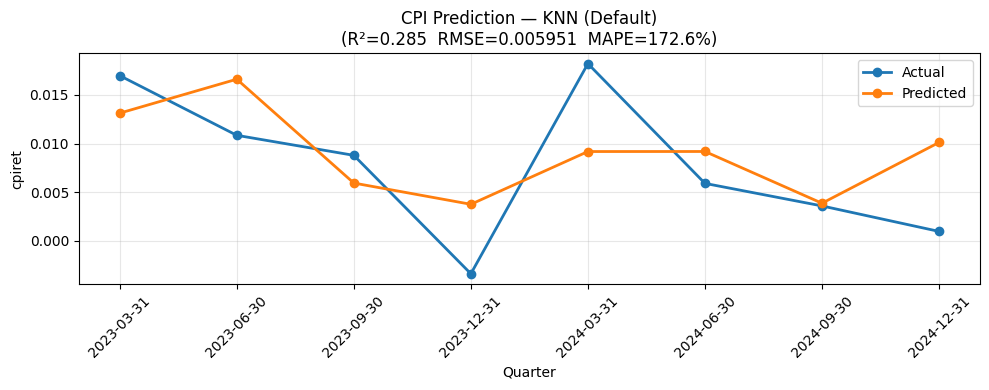

  0%|          | 0/128 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results, rmse, mae, mape, r2, knn_fi_std, knn_fi_shap, knn_fi_perm, knn_fi_lime = CPI_prediction(
    df, use_macro=False, model='KNN', use_scaling=True,
    importance_strategy='shap', tune=False
)

Total: 136 | Train: 128 | Test: 8 | Features: 42

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.007779     0.009199
2023-06-30          0.010843     0.012431     0.001588
2023-09-30          0.008784     0.003927     0.004857
2023-12-31         -0.003388     0.002753     0.006141
2024-03-31          0.018211     0.007308     0.010903
2024-06-30          0.005901     0.003922     0.001979
2024-09-30          0.003584     0.004122     0.000538
2024-12-31          0.000964     0.004294     0.003330
-----------------------------------------------------------------
                                        RMSE:     0.005944
                                    MAPE (%):        94.91
                                          R²:       0.2865


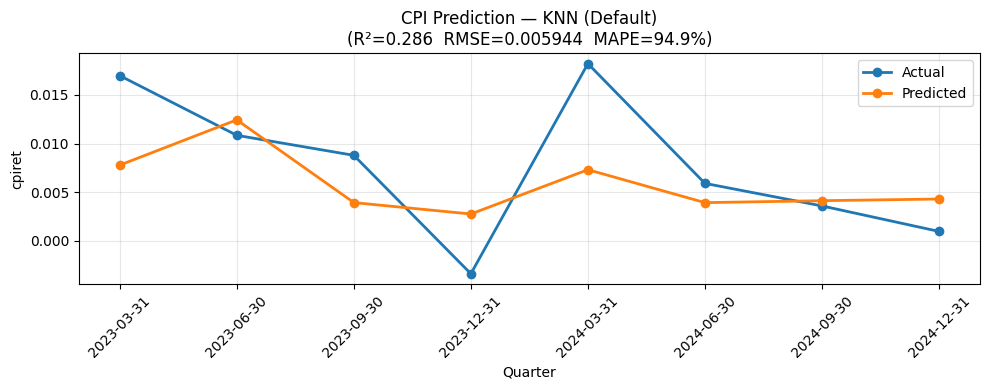

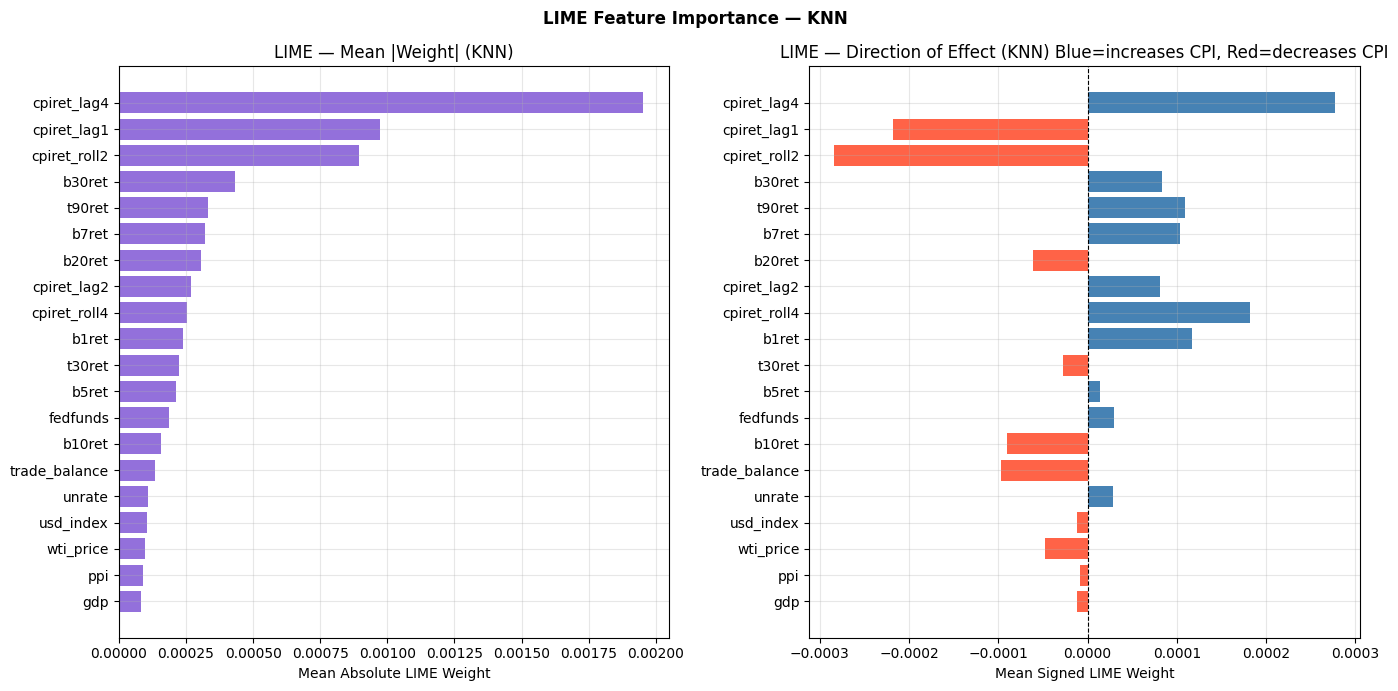

In [ ]:
results, rmse, mape, r2, knn_fi_std, knn_fi_shap, knn_fi_perm, knn_fi_lime = CPI_prediction(
    df, use_macro=True, model='KNN', use_scaling=True,
    feature_selection = False,
    importance_strategy='lime', tune=False
)

### SVR

Total: 136 | Train: 128 | Test: 8 | Features: 14

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.006494     0.010484
2023-06-30          0.010843     0.008705     0.002138
2023-09-30          0.008784     0.011104     0.002320
2023-12-31         -0.003388     0.001251     0.004639
2024-03-31          0.018211     0.010427     0.007784
2024-06-30          0.005901     0.003679     0.002222
2024-09-30          0.003584     0.002893     0.000691
2024-12-31          0.000964     0.005141     0.004177
-----------------------------------------------------------------
                                        RMSE:     0.005301
                                         MAE:        0.0043
                                    MAPE (%):        97.22
                                          R²:       0.4324


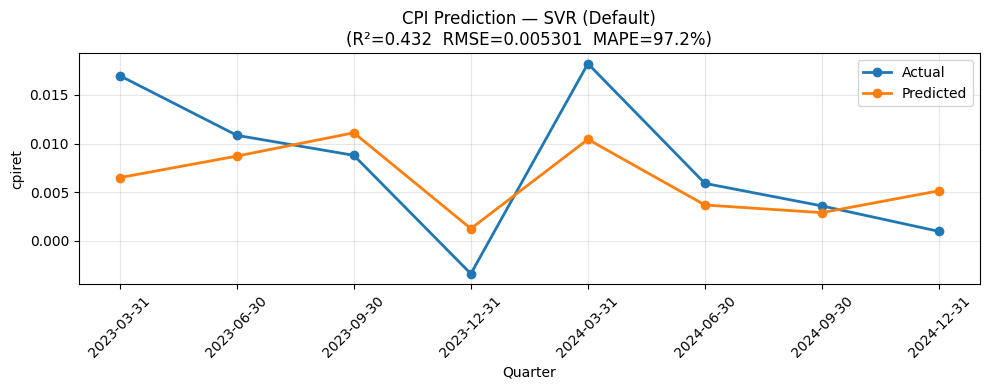

  0%|          | 0/128 [00:00<?, ?it/s]

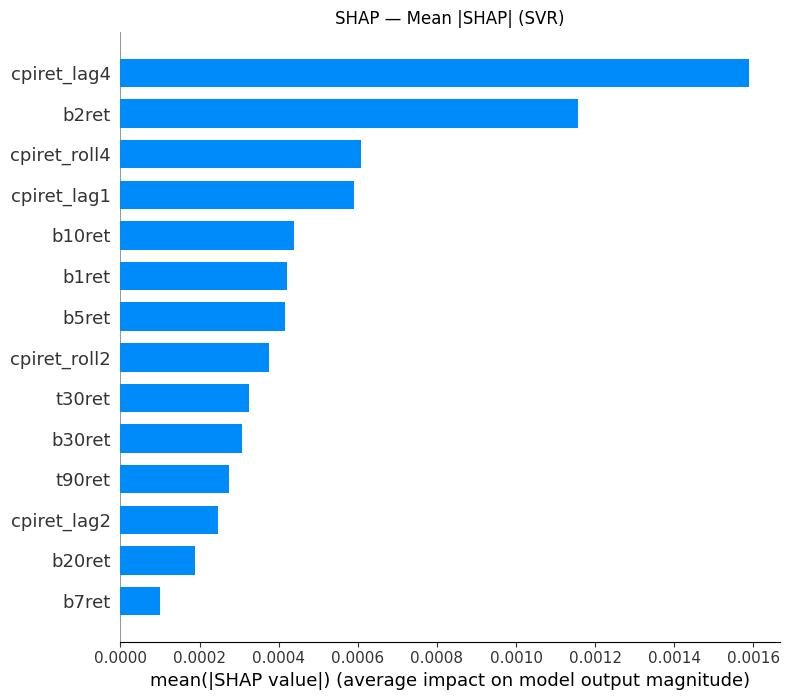

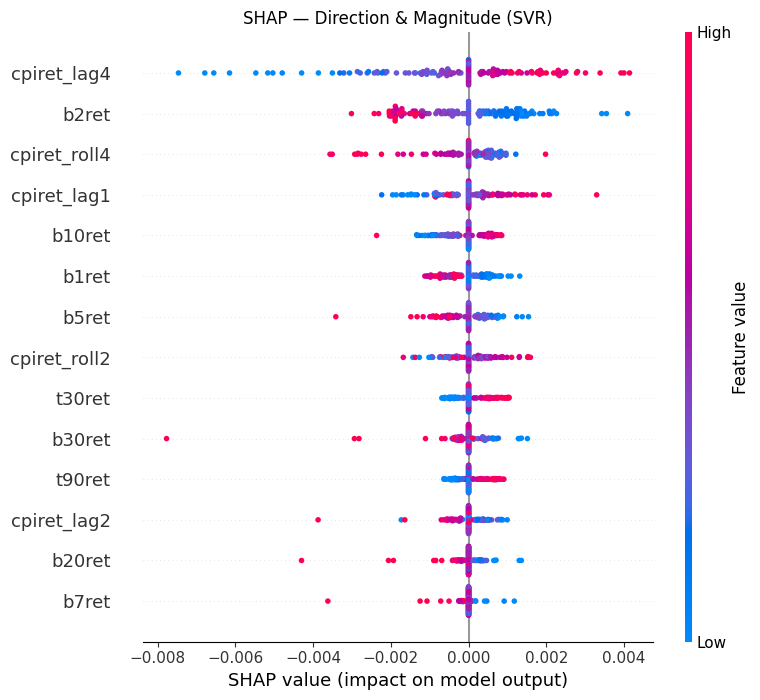

In [ ]:
results, rmse, mae, mape, r2, svr_fi_std, svr_fi_shap, svr_fi_perm, svr_fi_lime = CPI_prediction(
    df, use_macro=False, model='SVR', use_scaling=True,
    importance_strategy='shap', tune=False
)

Total: 136 | Train: 128 | Test: 8 | Features: 42

Tuning SVR with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: -0.1569
  Best params: {'model__kernel': 'rbf', 'model__gamma': 0.1, 'model__epsilon': 0.01, 'model__C': 100.0}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.006058     0.010920
2023-06-30          0.010843     0.006734     0.004109
2023-09-30          0.008784     0.006468     0.002316
2023-12-31         -0.003388     0.005859     0.009247
2024-03-31          0.018211     0.006398     0.011813
2024-06-30          0.005901     0.006218     0.000317
2024-09-30          0.003584     0.005910     0.002326
2024-12-31          0.000964     0.006309     0.005345
-----------------------------------------------------------------
                                        RMSE:     0.007077
                                    MAPE (%):       136.39
                         

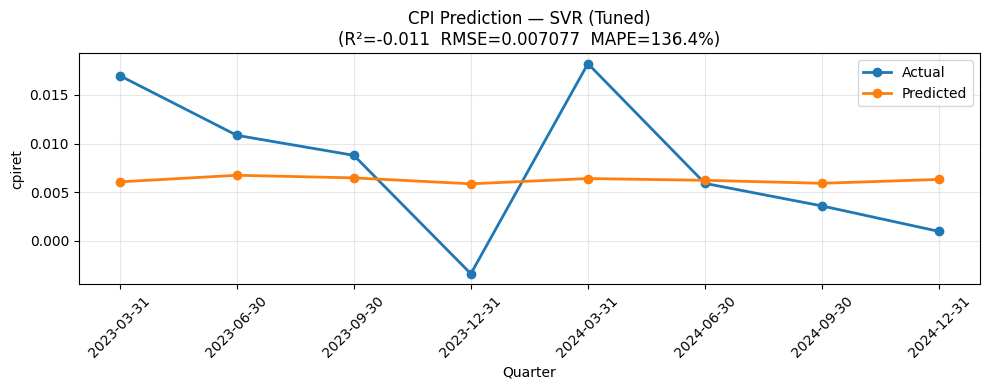

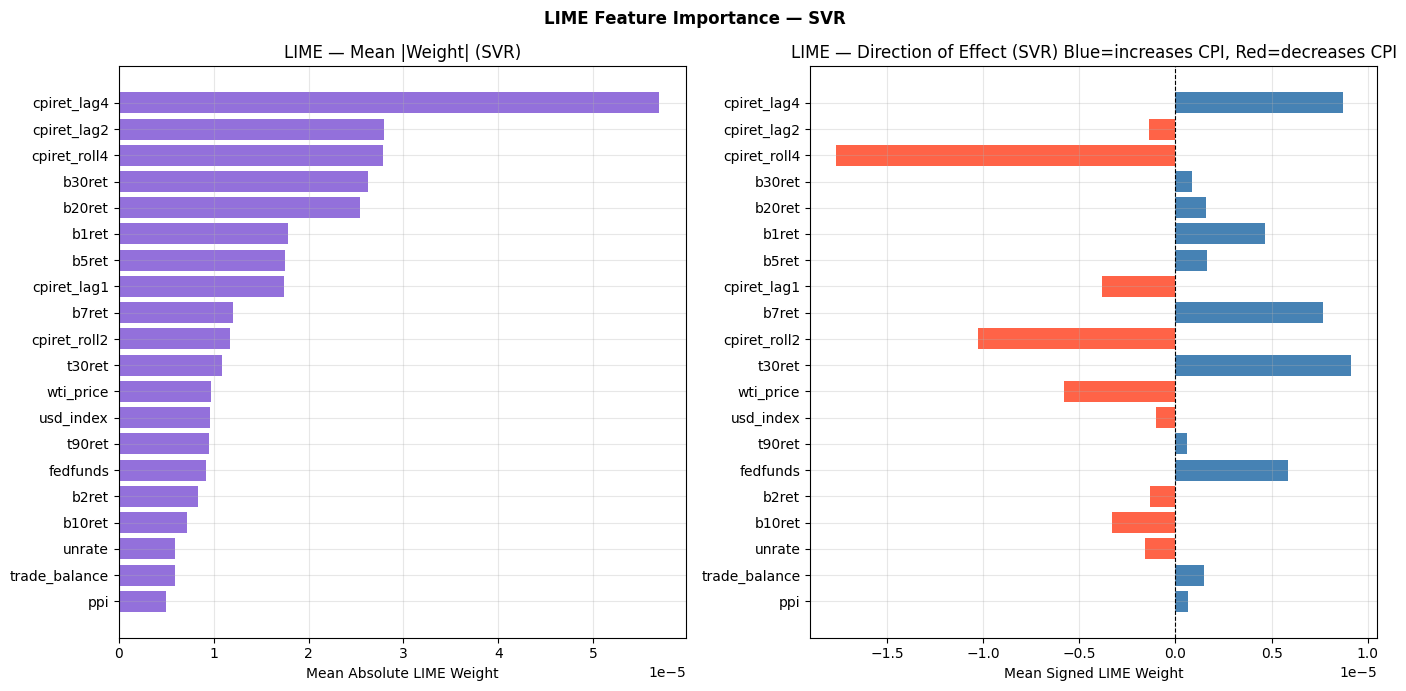

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm, fi_lime = CPI_prediction(
    df, use_macro=True, model='SVR', use_scaling=True,
    importance_strategy='lime', tune=True
)

### GB

Total: 136 | Train: 128 | Test: 8 | Features: 14

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.014296     0.002682
2023-06-30          0.010843     0.018093     0.007250
2023-09-30          0.008784     0.009195     0.000411
2023-12-31         -0.003388     0.000817     0.004205
2024-03-31          0.018211     0.013234     0.004977
2024-06-30          0.005901     0.009524     0.003623
2024-09-30          0.003584     0.006269     0.002685
2024-12-31          0.000964     0.002419     0.001455
-----------------------------------------------------------------
                                        RMSE:     0.003950
                                         MAE:        0.0034
                                    MAPE (%):        65.75
                                          R²:       0.6849


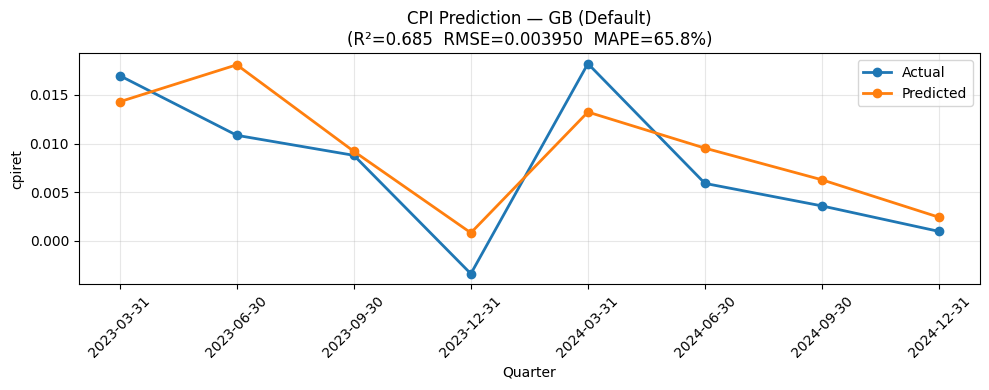

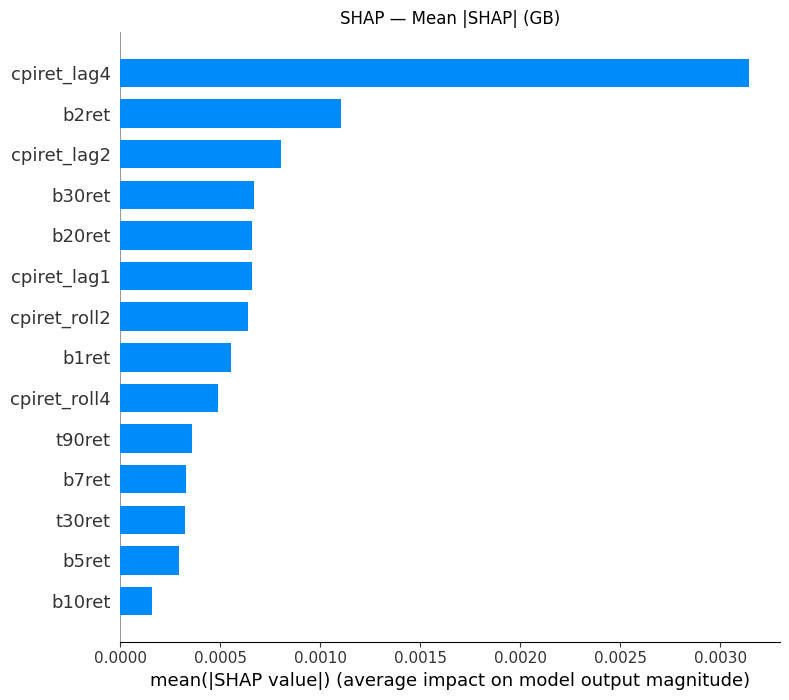

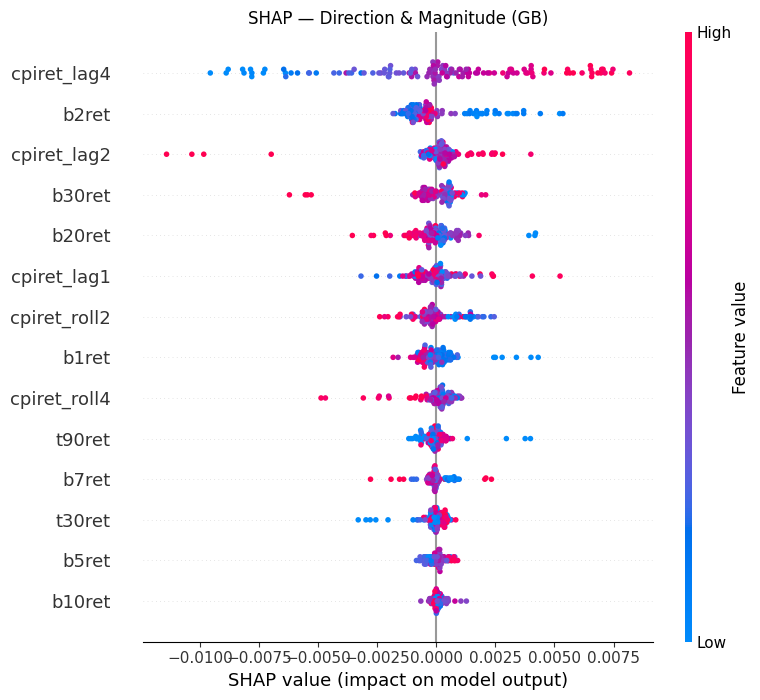

In [ ]:
results, rmse, mae, mape, r2, gb_fi_std, gb_fi_shap, gb_fi_perm, gb_fi_lime = CPI_prediction(
    df, use_macro=False, model='GB', use_scaling=True,
    importance_strategy='shap', tune=False
)

Total: 136 | Train: 128 | Test: 8 | Features: 42

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.010964     0.006014
2023-06-30          0.010843     0.020488     0.009645
2023-09-30          0.008784     0.008615     0.000169
2023-12-31         -0.003388    -0.000885     0.002503
2024-03-31          0.018211     0.015914     0.002297
2024-06-30          0.005901     0.010347     0.004446
2024-09-30          0.003584     0.004800     0.001216
2024-12-31          0.000964     0.003480     0.002516
-----------------------------------------------------------------
                                        RMSE:     0.004587
                                         MAE:        0.0036
                                    MAPE (%):        72.88
                                          R²:       0.5750


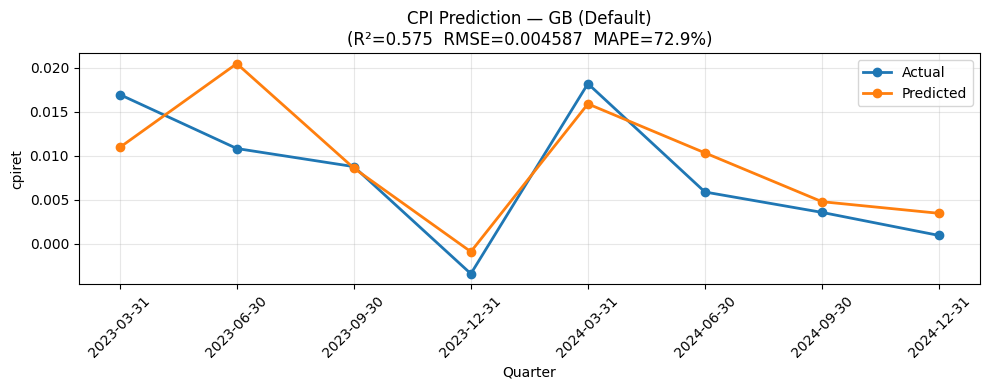

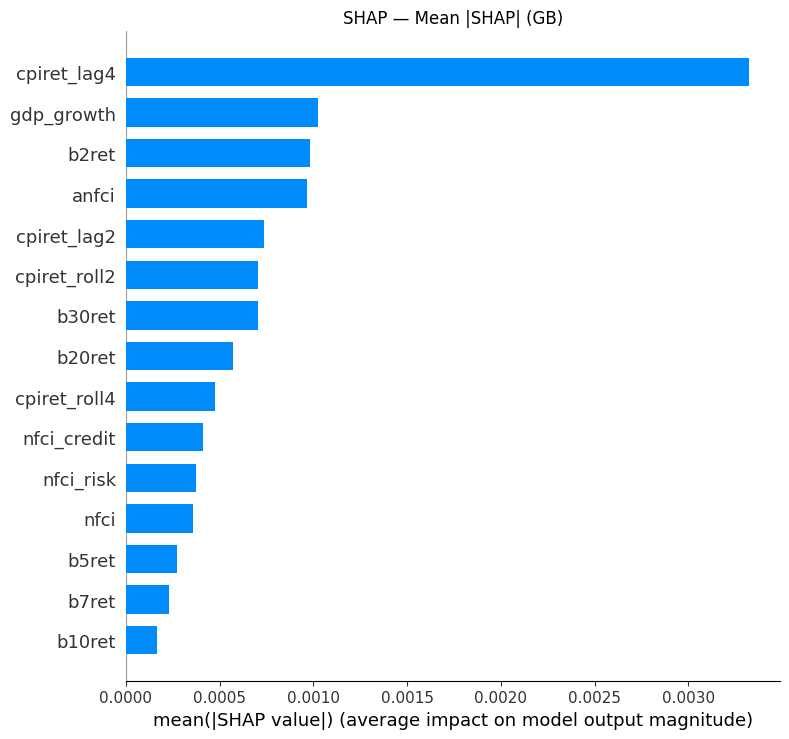

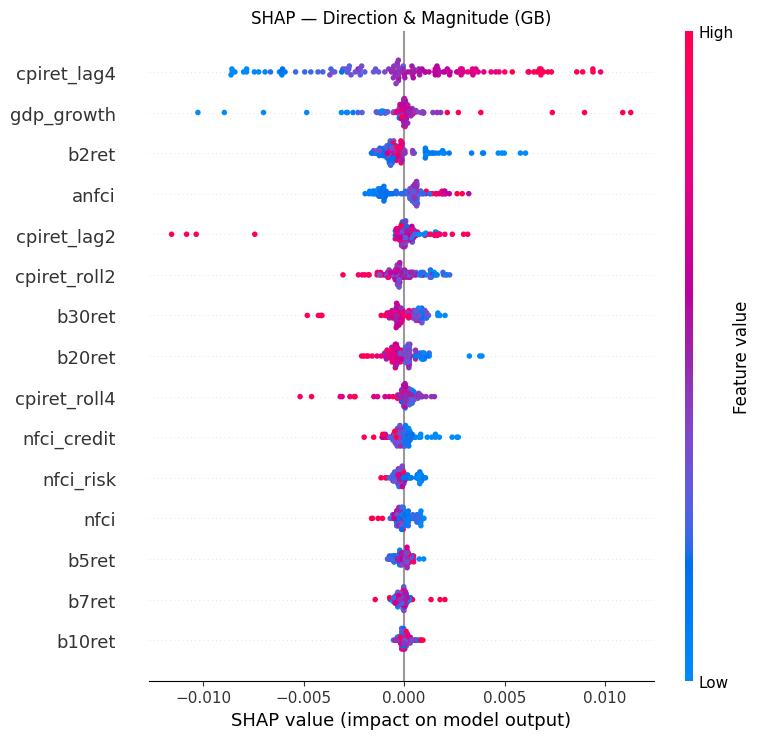

In [ ]:
results, rmse,mae,  mape, r2, gb_fi_std, gb_fi_shap, gb_fi_perm, gb_fi_lime = CPI_prediction(
    df, use_macro=True, model='GB', use_scaling=True, feature_selection=True,
    importance_strategy='shap', tune=False
)

### XGB

Total: 136 | Train: 128 | Test: 8 | Features: 14

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.009401     0.007577
2023-06-30          0.010843     0.011828     0.000985
2023-09-30          0.008784     0.006287     0.002497
2023-12-31         -0.003388     0.004167     0.007555
2024-03-31          0.018211     0.010901     0.007310
2024-06-30          0.005901     0.010494     0.004593
2024-09-30          0.003584     0.006178     0.002594
2024-12-31          0.000964     0.006105     0.005141
-----------------------------------------------------------------
                                        RMSE:     0.005355
                                         MAE:        0.0048
                                    MAPE (%):       128.60
                                          R²:       0.4209


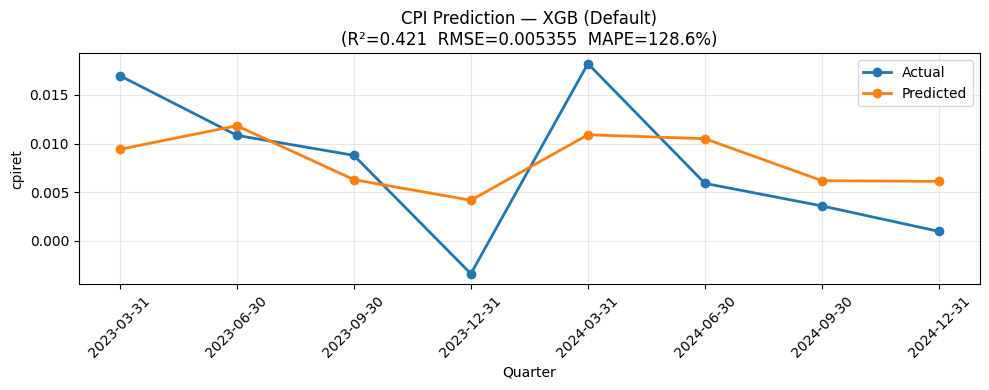

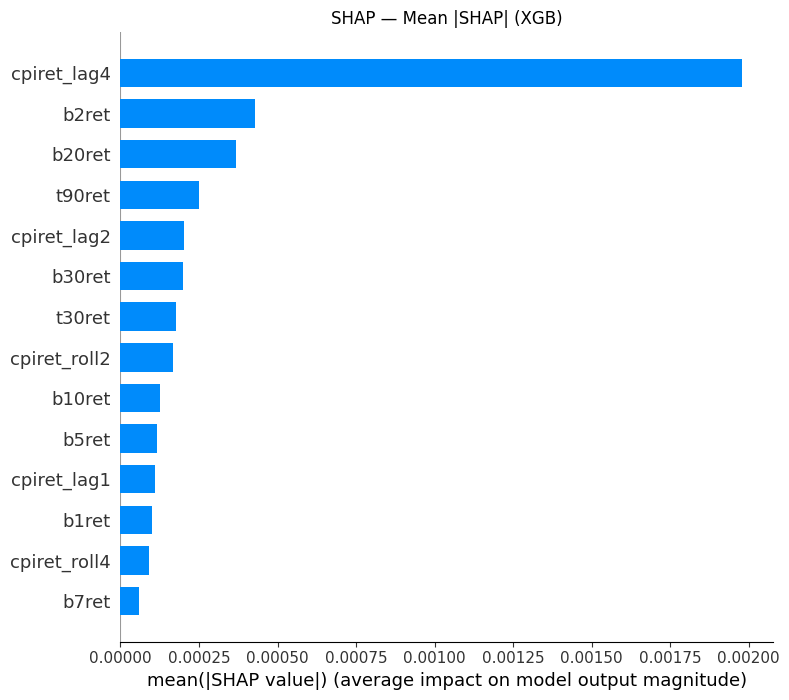

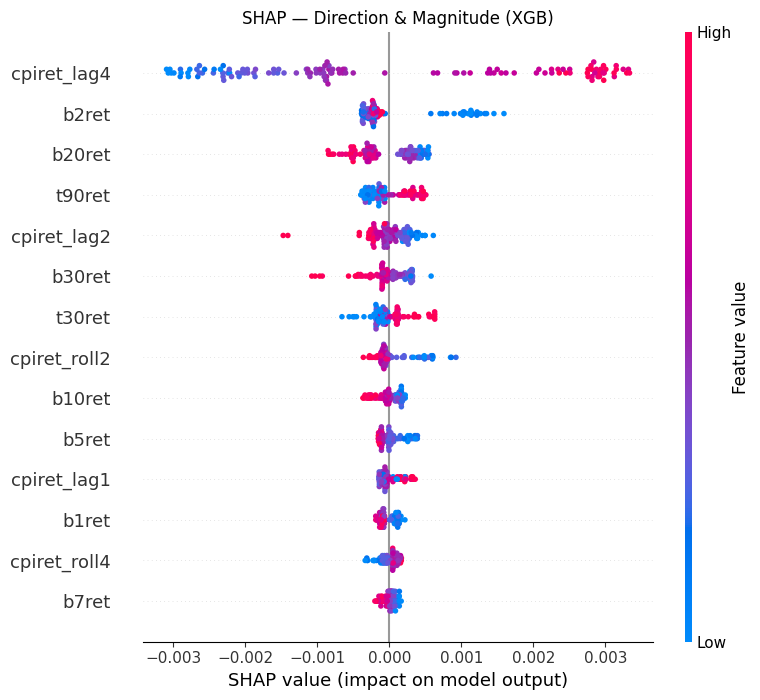

In [ ]:
results, rmse, mae, mape, r2, xgb_fi_std, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime = CPI_prediction(
    df, use_macro=False, model='XGB', use_scaling=True,
    importance_strategy='shap', tune=False
)

Total: 136 | Train: 128 | Test: 8 | Features: 42

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.009775     0.007203
2023-06-30          0.010843     0.012159     0.001316
2023-09-30          0.008784     0.005897     0.002887
2023-12-31         -0.003388     0.002851     0.006239
2024-03-31          0.018211     0.011011     0.007200
2024-06-30          0.005901     0.010607     0.004706
2024-09-30          0.003584     0.005850     0.002266
2024-12-31          0.000964     0.005646     0.004682
-----------------------------------------------------------------
                                        RMSE:     0.005024
                                    MAPE (%):       117.47
                                          R²:       0.4903


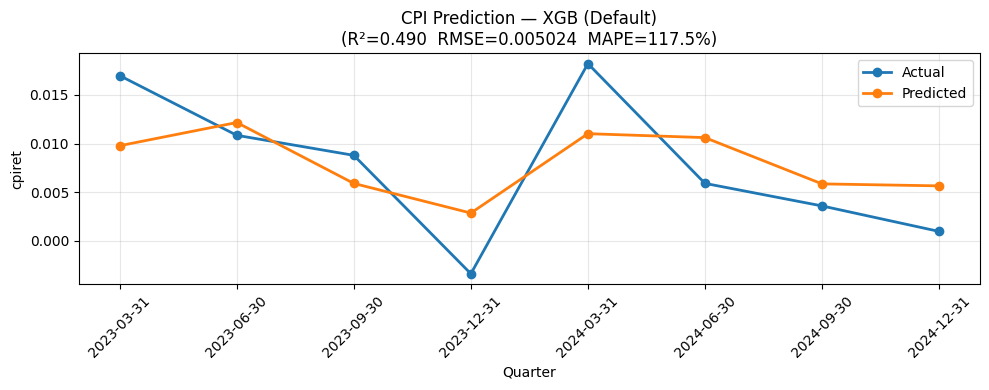

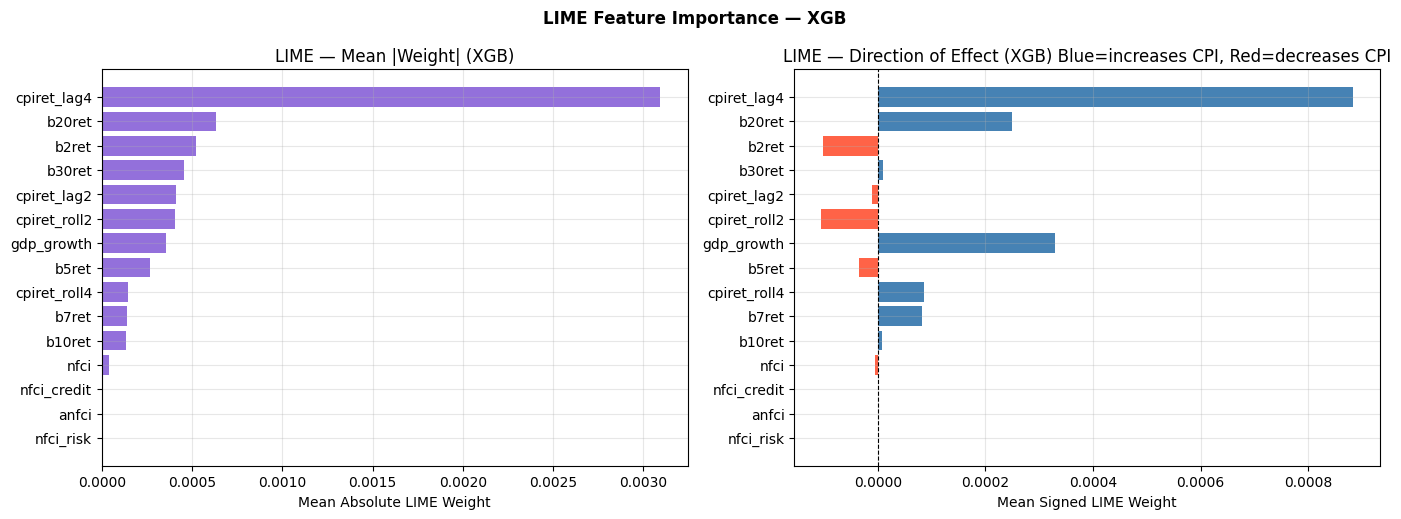

In [ ]:
results, rmse, mape, r2, xgb_fi_std, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime = CPI_prediction(
    df, use_macro=True, model='XGB', use_scaling=True, feature_selection=True,
    importance_strategy='lime', tune=False
)

### Catboost

Total: 136 | Train: 128 | Test: 8 | Features: 14

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.012089     0.004889
2023-06-30          0.010843     0.014036     0.003193
2023-09-30          0.008784     0.005931     0.002853
2023-12-31         -0.003388     0.003131     0.006519
2024-03-31          0.018211     0.014504     0.003707
2024-06-30          0.005901     0.008671     0.002770
2024-09-30          0.003584     0.006075     0.002491
2024-12-31          0.000964     0.003202     0.002238
-----------------------------------------------------------------
                                        RMSE:     0.003830
                                         MAE:        0.0036
                                    MAPE (%):        81.52
                                          R²:       0.7037


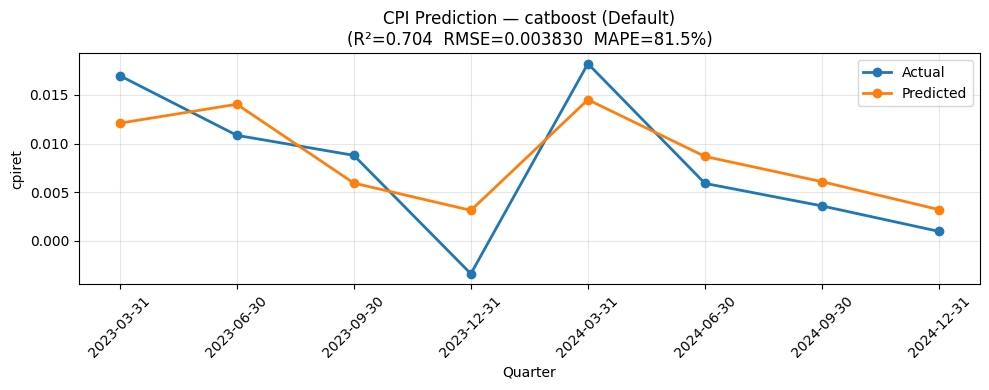

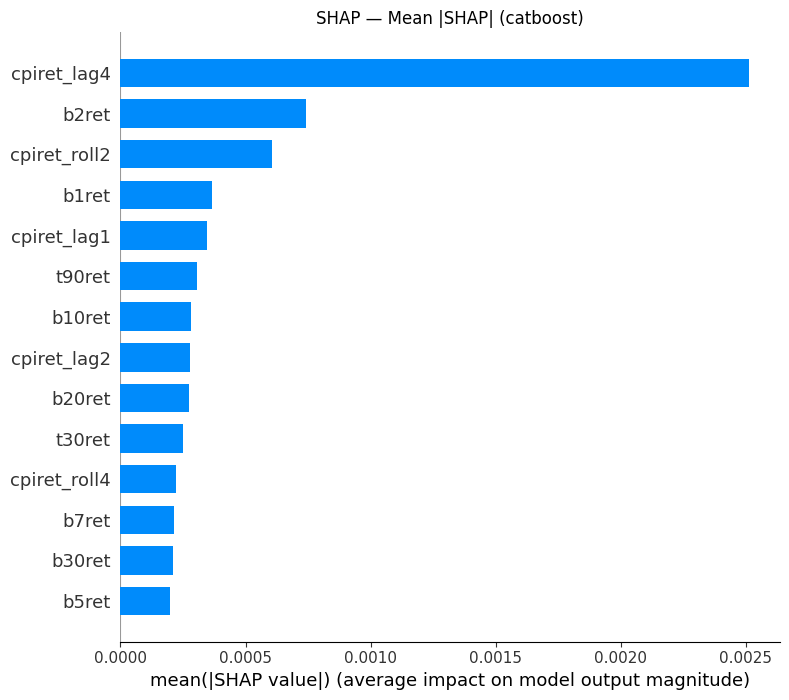

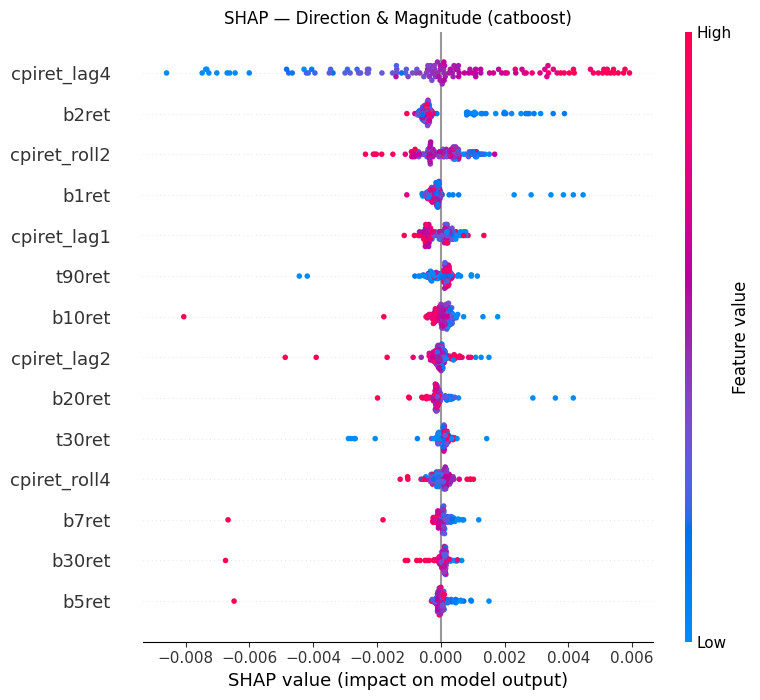

In [ ]:

results, rmse, mae, mape, r2, catboost_fi_std, catboost_fi_shap, catboost_fi_perm, catboost_f1_lime = CPI_prediction(
    df, use_macro=False, model='catboost', use_scaling=True,
    importance_strategy='shap', tune=False
)

Total: 136 | Train: 128 | Test: 8 | Features: 42

Tuning catboost with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: -0.0059
  Best params: {'model__subsample': 0.8, 'model__learning_rate': 0.01, 'model__l2_leaf_reg': 3.0, 'model__iterations': 300, 'model__depth': 6}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.008134     0.008844
2023-06-30          0.010843     0.012981     0.002138
2023-09-30          0.008784     0.007062     0.001722
2023-12-31         -0.003388     0.003988     0.007376
2024-03-31          0.018211     0.010723     0.007488
2024-06-30          0.005901     0.008118     0.002217
2024-09-30          0.003584     0.005191     0.001607
2024-12-31          0.000964     0.004346     0.003382
-----------------------------------------------------------------
                                        RMSE:     0.005186
                                    MAPE

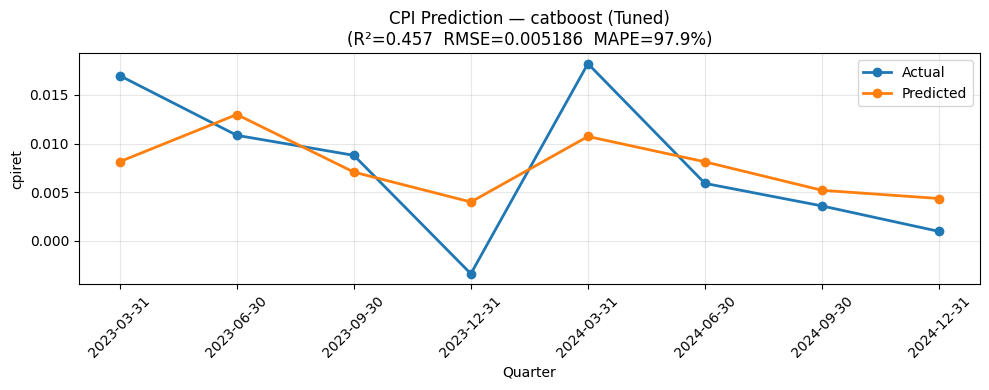

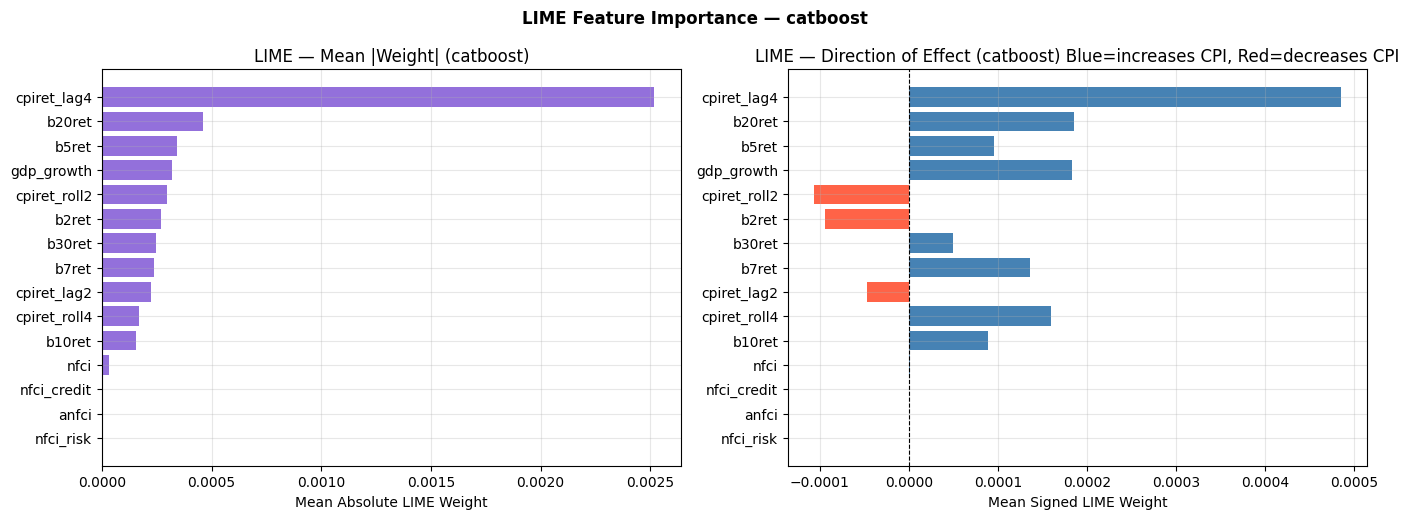

In [ ]:

results, rmse, mape, r2, catboost_fi_std, catboost_fi_shap, catboost_fi_perm, catboost_fi_lime = CPI_prediction(
    df, use_macro=True, model='catboost', use_scaling=True, feature_selection=True,
    importance_strategy='lime', tune=True
)

### bayes

Total: 136 | Train: 128 | Test: 8 | Features: 14

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: 0.1474
  Best params: {'model__max_iter': 1000, 'model__lambda_2': 1e-05, 'model__lambda_1': 1e-06, 'model__alpha_2': 1e-05, 'model__alpha_1': 1e-06}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.014827     0.002151
2023-06-30          0.010843     0.022812     0.011969
2023-09-30          0.008784     0.009085     0.000301
2023-12-31         -0.003388    -0.001686     0.001702
2024-03-31          0.018211     0.014322     0.003889
2024-06-30          0.005901     0.012091     0.006190
2024-09-30          0.003584     0.003279     0.000305
2024-12-31          0.000964     0.006333     0.005369
-----------------------------------------------------------------
                                        RMSE:     0.005399
                                         MAE

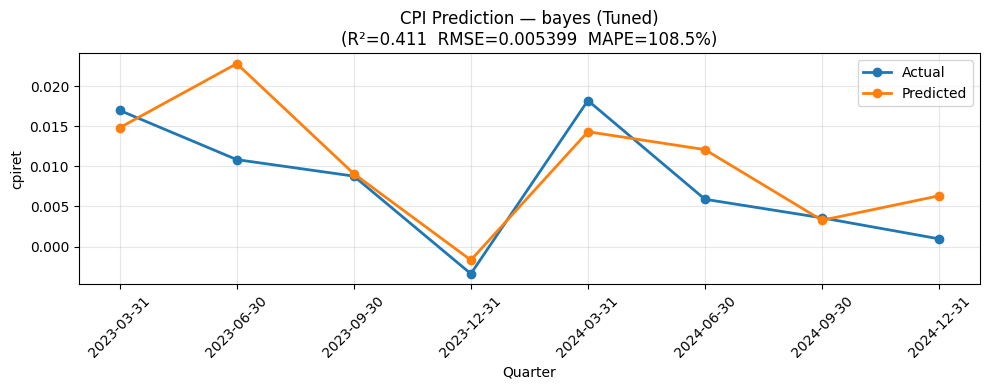

  0%|          | 0/128 [00:00<?, ?it/s]

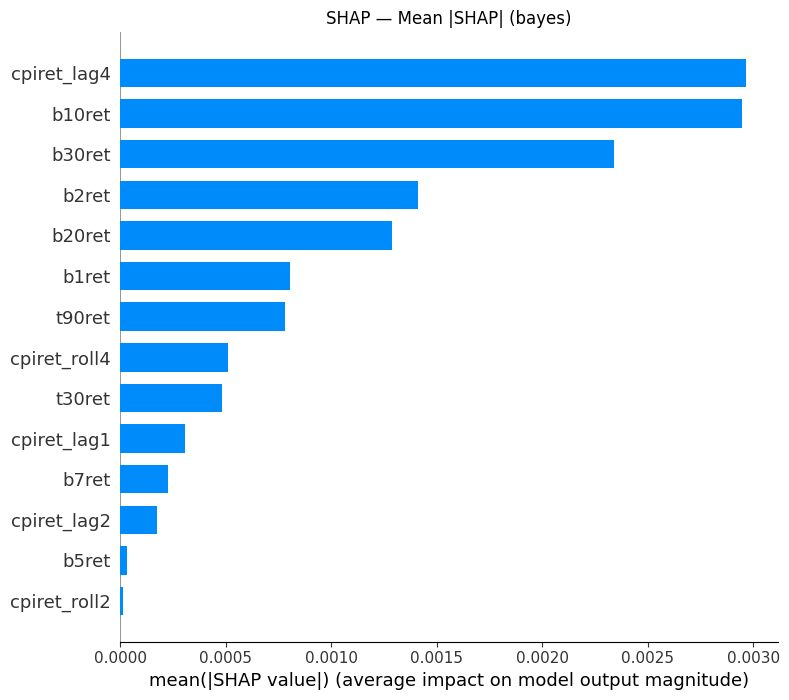

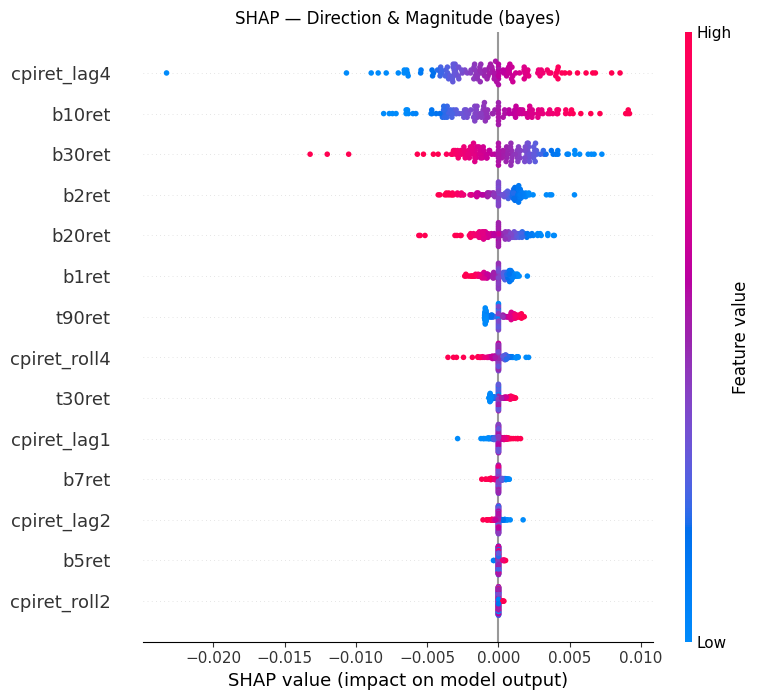

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_std, bayes_fi_shap, bayes_fi_perm, bayes_f1_lime = CPI_prediction(
    df, use_macro=False, model='bayes',
    use_scaling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True
)

Total: 136 | Train: 128 | Test: 8 | Features: 42

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.014993     0.001985
2023-06-30          0.010843     0.017668     0.006825
2023-09-30          0.008784     0.007187     0.001597
2023-12-31         -0.003388    -0.002530     0.000858
2024-03-31          0.018211     0.012123     0.006088
2024-06-30          0.005901     0.008439     0.002538
2024-09-30          0.003584     0.006197     0.002613
2024-12-31          0.000964     0.006159     0.005195
-----------------------------------------------------------------
                                        RMSE:     0.004049
                                         MAE:        0.0035
                                    MAPE (%):       100.79
                                          R²:       0.6689


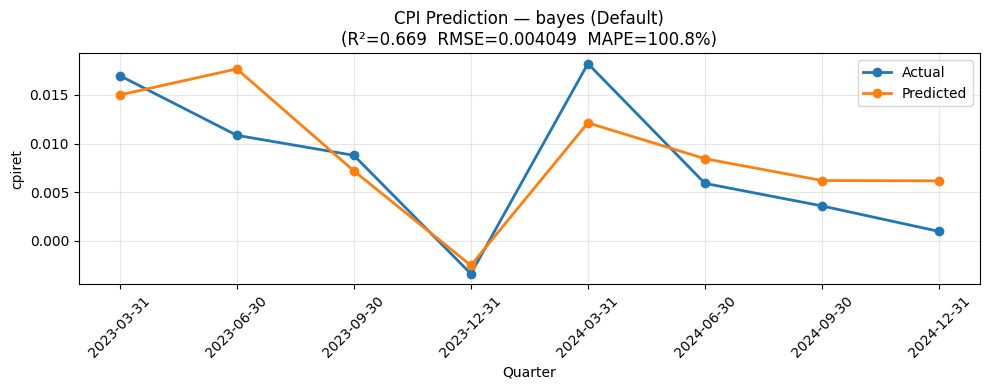

  0%|          | 0/128 [00:00<?, ?it/s]

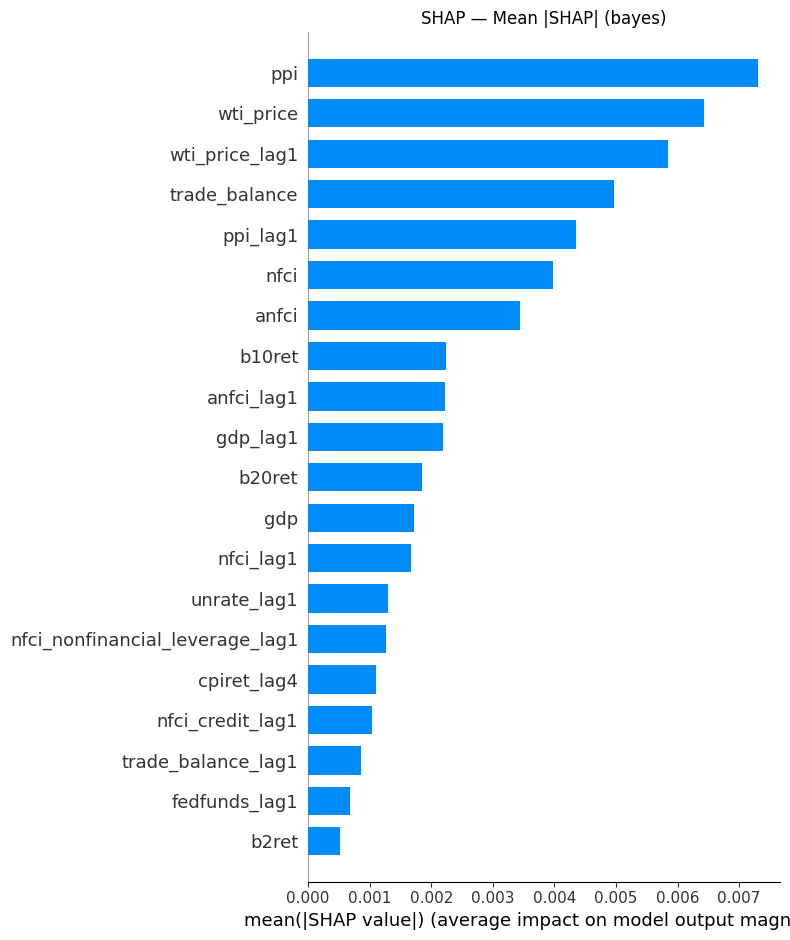

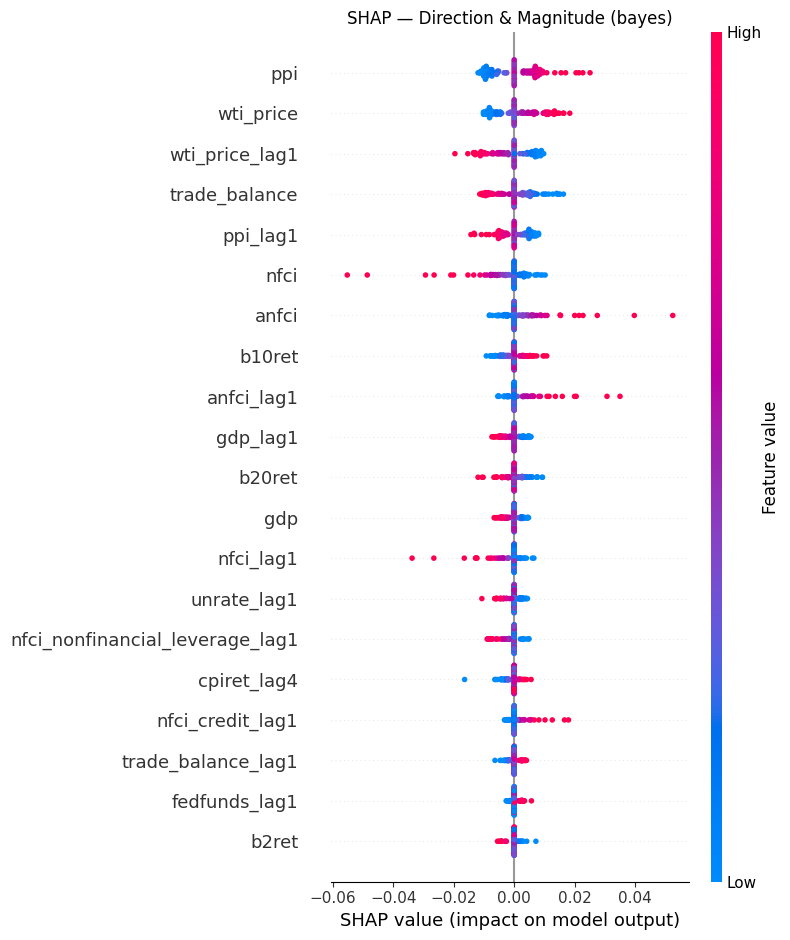

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_standard, bayes_fi_shap, bayes_fi_perm, bayes_fi_lime = CPI_prediction(
    df, use_macro=True, model='bayes',
    use_scaling=True, feature_selection=False,
    importance_strategy='shap',
    tune=False
)

### Arima

Total: 136 | Train: 128 | Test: 8 | Features: 14

ARIMA — Best AIC: -828.34
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.018823     0.001845
2023-06-30          0.010843     0.019663     0.008820
2023-09-30          0.008784     0.001063     0.007721
2023-12-31         -0.003388    -0.000027     0.003361
2024-03-31          0.018211     0.012195     0.006016
2024-06-30          0.005901     0.012739     0.006838
2024-09-30          0.003584     0.000689     0.002895
2024-12-31          0.000964    -0.000018     0.000982
-----------------------------------------------------------------
                                        RMSE:     0.005527
                                         MAE:        0.0048
                                    MAPE (%):        76.36
                                          R²:       0.3829

Note: ARIMA coefficients:
ar.L1      0.131327
ar.S.L4    0.

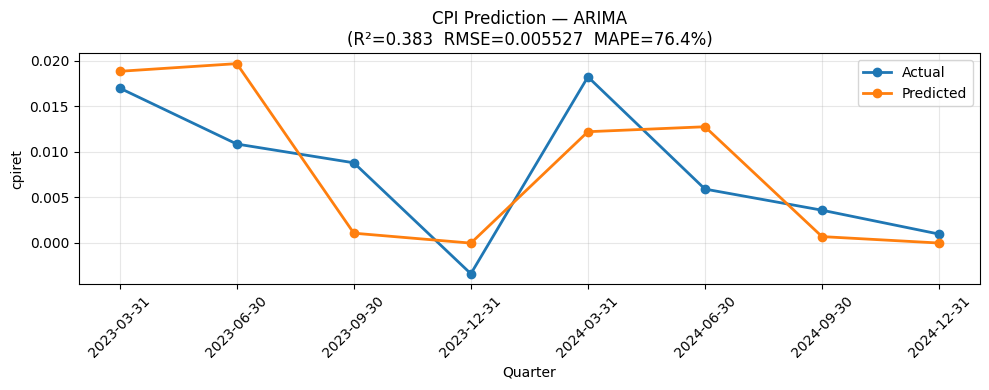

In [ ]:
results, rmse, mae, mape, r2 = CPI_prediction(
    df, use_macro=False, model='arima',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 42


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


ARIMA — Best AIC: -990.28
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.012231     0.004747
2023-06-30          0.010843     0.015513     0.004670
2023-09-30          0.008784     0.012041     0.003257
2023-12-31         -0.003388    -0.008672     0.005284
2024-03-31          0.018211     0.014925     0.003286
2024-06-30          0.005901     0.008589     0.002688
2024-09-30          0.003584     0.003121     0.000463
2024-12-31          0.000964     0.003660     0.002696
-----------------------------------------------------------------
                                        RMSE:     0.003681
                                         MAE:        0.0040
                                    MAPE (%):        77.53
                                          R²:       0.7264

Note: ARIMA coefficients:
x1         2.316008e-02
x2        -4.778360e-02
x3         3.192137e-02
x4        

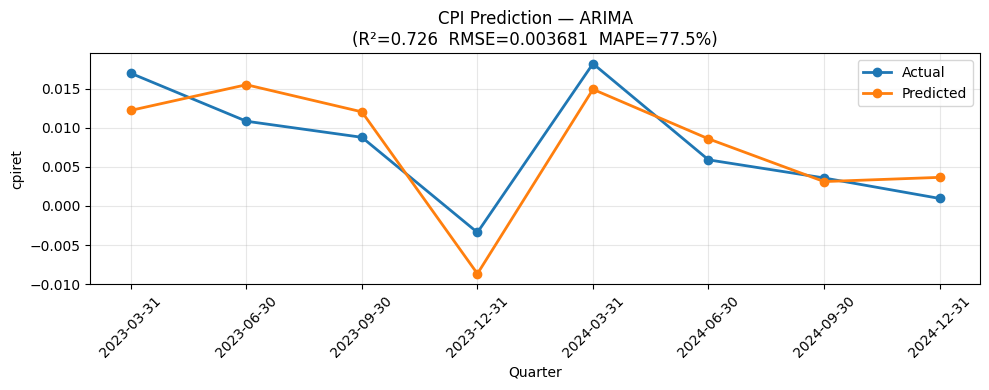

In [ ]:
results, rmse, mae, mape, r2 = CPI_prediction(
    df, use_macro=True, model='arima',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

### Regresssion TM

Total: 136 | Train: 128 | Test: 8 | Features: 14


  0%|          | 0/30 [00:00<?, ?it/s]


Bayes + Tsetlin Residual Corrector
Base R²: 0.1783  →  Final R²: 0.2848
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.01
2023-06-30              0.01         0.02         0.00
2023-09-30              0.01         0.01         0.00
2023-12-31             -0.00         0.00         0.01
2024-03-31              0.02         0.01         0.01
2024-06-30              0.01         0.01         0.00
2024-09-30              0.00         0.01         0.00
2024-12-31              0.00         0.01         0.01
-----------------------------------------------------------------
                                         MAE: 0.0052
                                        RMSE: 0.0060
                                    MAPE (%): 167.87
                                          R²: 0.2848


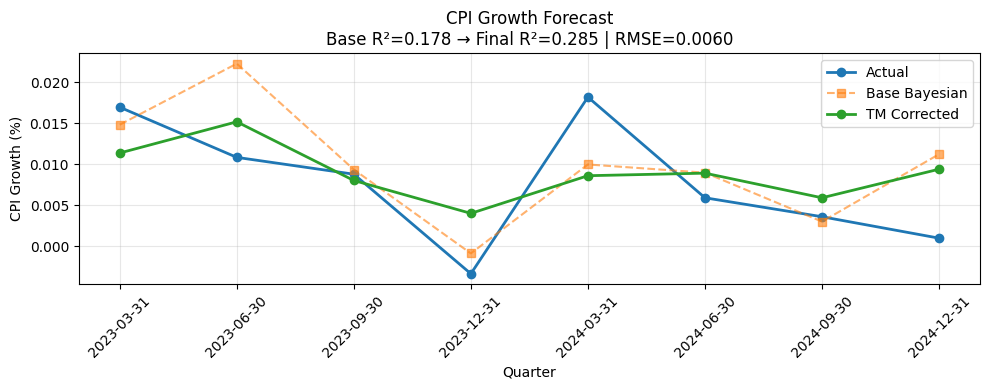

In [ ]:
results, rmse, mae, mape, r2, fi_perm = CPI_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=True, tune=True
)

Total: 136 | Train: 128 | Test: 8 | Features: 28


  0%|          | 0/30 [00:00<?, ?it/s]


Bayes + Tsetlin Residual Corrector
Base R²: 0.2261  →  Final R²: -0.0616
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.02         0.00
2023-06-30              0.01         0.02         0.01
2023-09-30              0.01         0.01         0.00
2023-12-31             -0.00         0.00         0.01
2024-03-31              0.02         0.01         0.01
2024-06-30              0.01         0.01         0.01
2024-09-30              0.00         0.01         0.00
2024-12-31              0.00         0.01         0.01
-----------------------------------------------------------------
                                         MAE: 0.0062
                                        RMSE: 0.0072
                                    MAPE (%): 241.16
                                          R²: -0.0616


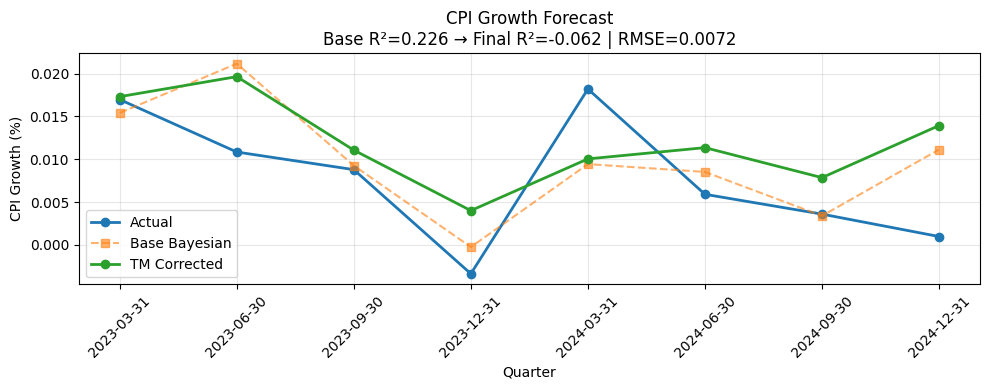

In [ ]:
results, rmse, mae, mape, r2, fi_perm = CPI_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=True, test_quarters=8,
    tune=True, n_iter=30
)

## Aggregate feature importance

In [ ]:
def _classify(feature: str) -> str:
    base = feature.replace("_lag1", "").replace("_lag2", "").replace("_lag4", "")
    return "macro" if base in macro_vars else "micro"

In [ ]:

def _build_matrices(importance_results: dict):
    model_names  = list(importance_results.keys())
    n_models     = len(model_names)

    all_features = sorted(
        set(f for fi in importance_results.values() for f in fi['feature'])
    )
    n_features = len(all_features)

    rank_matrix  = pd.DataFrame(index=all_features, columns=model_names, dtype=float)
    score_matrix = pd.DataFrame(index=all_features, columns=model_names, dtype=float)

    for model_name, fi_df in importance_results.items():
        fi_df = fi_df.copy().reset_index(drop=True)
        fi_df['rank'] = fi_df['importance'].rank(ascending=False, method='min')

        imp_min = fi_df['importance'].min()
        imp_max = fi_df['importance'].max()
        denom   = imp_max - imp_min if imp_max != imp_min else 1.0
        fi_df['norm_score'] = (fi_df['importance'] - imp_min) / denom

        for _, row in fi_df.iterrows():
            rank_matrix.loc[row['feature'],  model_name] = row['rank']
            score_matrix.loc[row['feature'], model_name] = row['norm_score']

        for f in set(all_features) - set(fi_df['feature']):
            rank_matrix.loc[f,  model_name] = n_features + 1
            score_matrix.loc[f, model_name] = 0.0

    return model_names, all_features, n_features, rank_matrix, score_matrix

In [ ]:
def _compute_all_methods(model_names, all_features, n_features,
                          rank_matrix, score_matrix) -> pd.DataFrame:
    # Borda
    borda_scores = sum(
        (n_features + 1) - rank_matrix[m] for m in model_names
    )

    # Mean rank
    mean_rank = rank_matrix.mean(axis=1)
    std_rank  = rank_matrix.std(axis=1)

    # Mean normalised score
    mean_score = score_matrix.mean(axis=1)
    std_score  = score_matrix.std(axis=1)

    combined = pd.DataFrame({
        'feature':          all_features,
        'borda_score':      borda_scores.values,
        'mean_rank':        mean_rank.values,
        'std_rank':         std_rank.values,
        'mean_score':       mean_score.values,
        'std_score':        std_score.values,
        'consistency':      (1 / (std_rank.values + 1e-6)),
        'var_group':        [_classify(f) for f in all_features],
    })
    return combined


def _plot_group(ax, features, scores, errs, title, xlabel,
                color, invert_x=False, method_key='borda'):
    if len(features) == 0:
        ax.text(0.5, 0.5, 'No features in this group',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
        return

    y = range(len(features))
    if errs is not None:
        ax.barh(list(y), scores, xerr=errs, color=color,
                alpha=0.85, capsize=3, edgecolor='white', linewidth=0.4)
    else:
        ax.barh(list(y), scores, color=color,
                alpha=0.85, edgecolor='white', linewidth=0.4)

    ax.set_yticks(list(y))
    ax.set_yticklabels(features, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    if invert_x:
        ax.invert_xaxis()
    ax.grid(True, axis='x', alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    # Inline value labels
    for i, (s, feat) in enumerate(zip(scores, features)):
        ax.text(s * (0.98 if not invert_x else 1.02),
                i, f"{s:.3f}", va='center',
                ha='right' if not invert_x else 'left',
                fontsize=7, color='#333333')


def aggregate_feature_importance(importance_results: dict,
                                  top_n: int = 20) -> pd.DataFrame:
    model_names, all_features, n_features, rank_matrix, score_matrix = \
        _build_matrices(importance_results)

    combined = _compute_all_methods(
        model_names, all_features, n_features, rank_matrix, score_matrix
    )

    n_models = len(model_names)

    for method_key, sort_col, ascending, label in [
        ('borda',      'borda_score', False, 'BORDA COUNT'),
        ('mean_rank',  'mean_rank',   True,  'MEAN RANK'),
        ('mean_score', 'mean_score',  False, 'MEAN NORMALISED SCORE'),
    ]:
        ranked = combined.sort_values(sort_col, ascending=ascending).head(top_n)
        print(f"\n{'='*75}")
        print(f"AGGREGATED FEATURE IMPORTANCE — {label} ({n_models} models)")
        print(f"{'='*75}")
        print(f"{'Rank':<6} {'Feature':<35} {'Borda':>8} "
              f"{'MeanRank':>10} {'MeanScore':>10} {'Group':>7}")
        print(f"{'-'*75}")
        for i, (_, row) in enumerate(ranked.iterrows()):
            print(f"{i+1:<6} {row['feature']:<35} "
                  f"{row['borda_score']:>8.1f} "
                  f"{row['mean_rank']:>10.2f} "
                  f"{row['mean_score']:>10.4f} "
                  f"{row['var_group']:>7}")
        print(f"{'='*75}")

    METHOD_CFG = [
        ('borda_score', False, 'borda_score', None,
         'Borda Score (higher = more important)',
         '#2E86AB', False, 'Borda Count'),

        ('mean_rank', True, 'mean_rank', 'std_rank',
         'Mean Rank (lower = more important, ±std)',
         '#E07A5F', True, 'Mean Rank'),

        ('mean_score', False, 'mean_score', 'std_score',
         'Mean Normalised Score (higher = more important, ±std)',
         '#3D9970', False, 'Mean Norm. Score'),
    ]

    GROUPS = [
        ('macro', 'Macro Variables'),
        ('micro', 'Micro Variables'),
    ]

    fig, axes = plt.subplots(
        3, 2,
        figsize=(18, top_n * 0.55 + 3),
        constrained_layout=True
    )

    fig.suptitle(
        f'Feature Importance Aggregation',
        fontsize=13, fontweight='bold', y=1.01
    )

    for row_idx, (sort_col, ascending, score_col, err_col,
                  xlabel, color, invert_x, method_label) in enumerate(METHOD_CFG):

        for col_idx, (group_key, group_label) in enumerate(GROUPS):

            ax = axes[row_idx][col_idx]

            # Filter to this variable group, sort by this method
            subset = (combined[combined['var_group'] == group_key]
                      .sort_values(sort_col, ascending=ascending)
                      .head(top_n))

            features = subset['feature'].tolist()[::-1]   # flip for barh
            scores   = subset[score_col].tolist()[::-1]
            errs     = subset[err_col].tolist()[::-1] if err_col else None

            title = f"{method_label}  |  {group_label}"
            _plot_group(ax, features, scores, errs,
                        title, xlabel, color, invert_x, method_key=sort_col)

    plt.savefig("feature_importance_CPI.png", dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

    return combined


def plot_model_agreement(importance_results: dict, top_n: int):
    model_names = list(importance_results.keys())
    vote_counts = {}

    for model_name, fi_df in importance_results.items():
        for f in fi_df.nlargest(top_n, 'importance')['feature']:
            vote_counts[f] = vote_counts.get(f, 0) + 1

    vote_df = (pd.DataFrame({
        'feature': list(vote_counts.keys()),
        'votes':   list(vote_counts.values()),
        'group':   [_classify(f) for f in vote_counts]
    }).sort_values('votes', ascending=False).reset_index(drop=True))

    print(f"\n{'='*55}")
    print(f"MODEL AGREEMENT — Top {top_n} features per model")
    print(f"{'='*55}")
    for _, row in vote_df.iterrows():
        bar = '█' * row['votes']
        pct = row['votes'] / len(model_names) * 100
        print(f"  {row['feature']:<30} {bar:<10} "
              f"{row['votes']}/{len(model_names)} ({pct:.0f}%)  [{row['group']}]")
    print(f"{'='*55}")

    fig, ax = plt.subplots(figsize=(8, max(4, len(vote_df) * 0.35)))
    colors = ['darkgreen' if v == len(model_names)
              else 'steelblue' if v >= len(model_names) * 0.6
              else 'salmon'
              for v in vote_df['votes'][::-1]]
    ax.barh(vote_df['feature'][::-1], vote_df['votes'][::-1], color=colors)
    ax.axvline(len(model_names), color='black', linestyle='--',
               linewidth=1, label=f'All {len(model_names)} models')
    ax.axvline(len(model_names) * 0.6, color='orange', linestyle='--',
               linewidth=1, label='60% of models')
    ax.set_xlabel(f"Number of models featuring in top {top_n}")
    ax.set_title(f"Feature Agreement Across Models\n"
                 f"(green = in top {top_n} of ALL models)")
    ax.set_xlim(0, len(model_names) + 0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return vote_df


AGGREGATED FEATURE IMPORTANCE — BORDA COUNT (4 models)
Rank   Feature                                Borda   MeanRank  MeanScore   Group
---------------------------------------------------------------------------
1      cpiret_lag4                            153.0       4.75     0.7876   micro
2      b2ret                                  145.0       6.75     0.1891   micro
3      b20ret                                 141.0       7.75     0.1442   micro
4      b10ret                                 133.0       9.75     0.0945   micro
5      cpiret_roll2                           132.0      10.00     0.1094   micro
6      cpiret_lag2                            121.0      12.75     0.0727   micro
7      b30ret                                 116.0      14.00     0.0632   micro
8      cpiret_roll4                           106.0      16.50     0.0313   micro
9      b7ret                                  106.0      16.50     0.0108   micro
10     b5ret                                  10

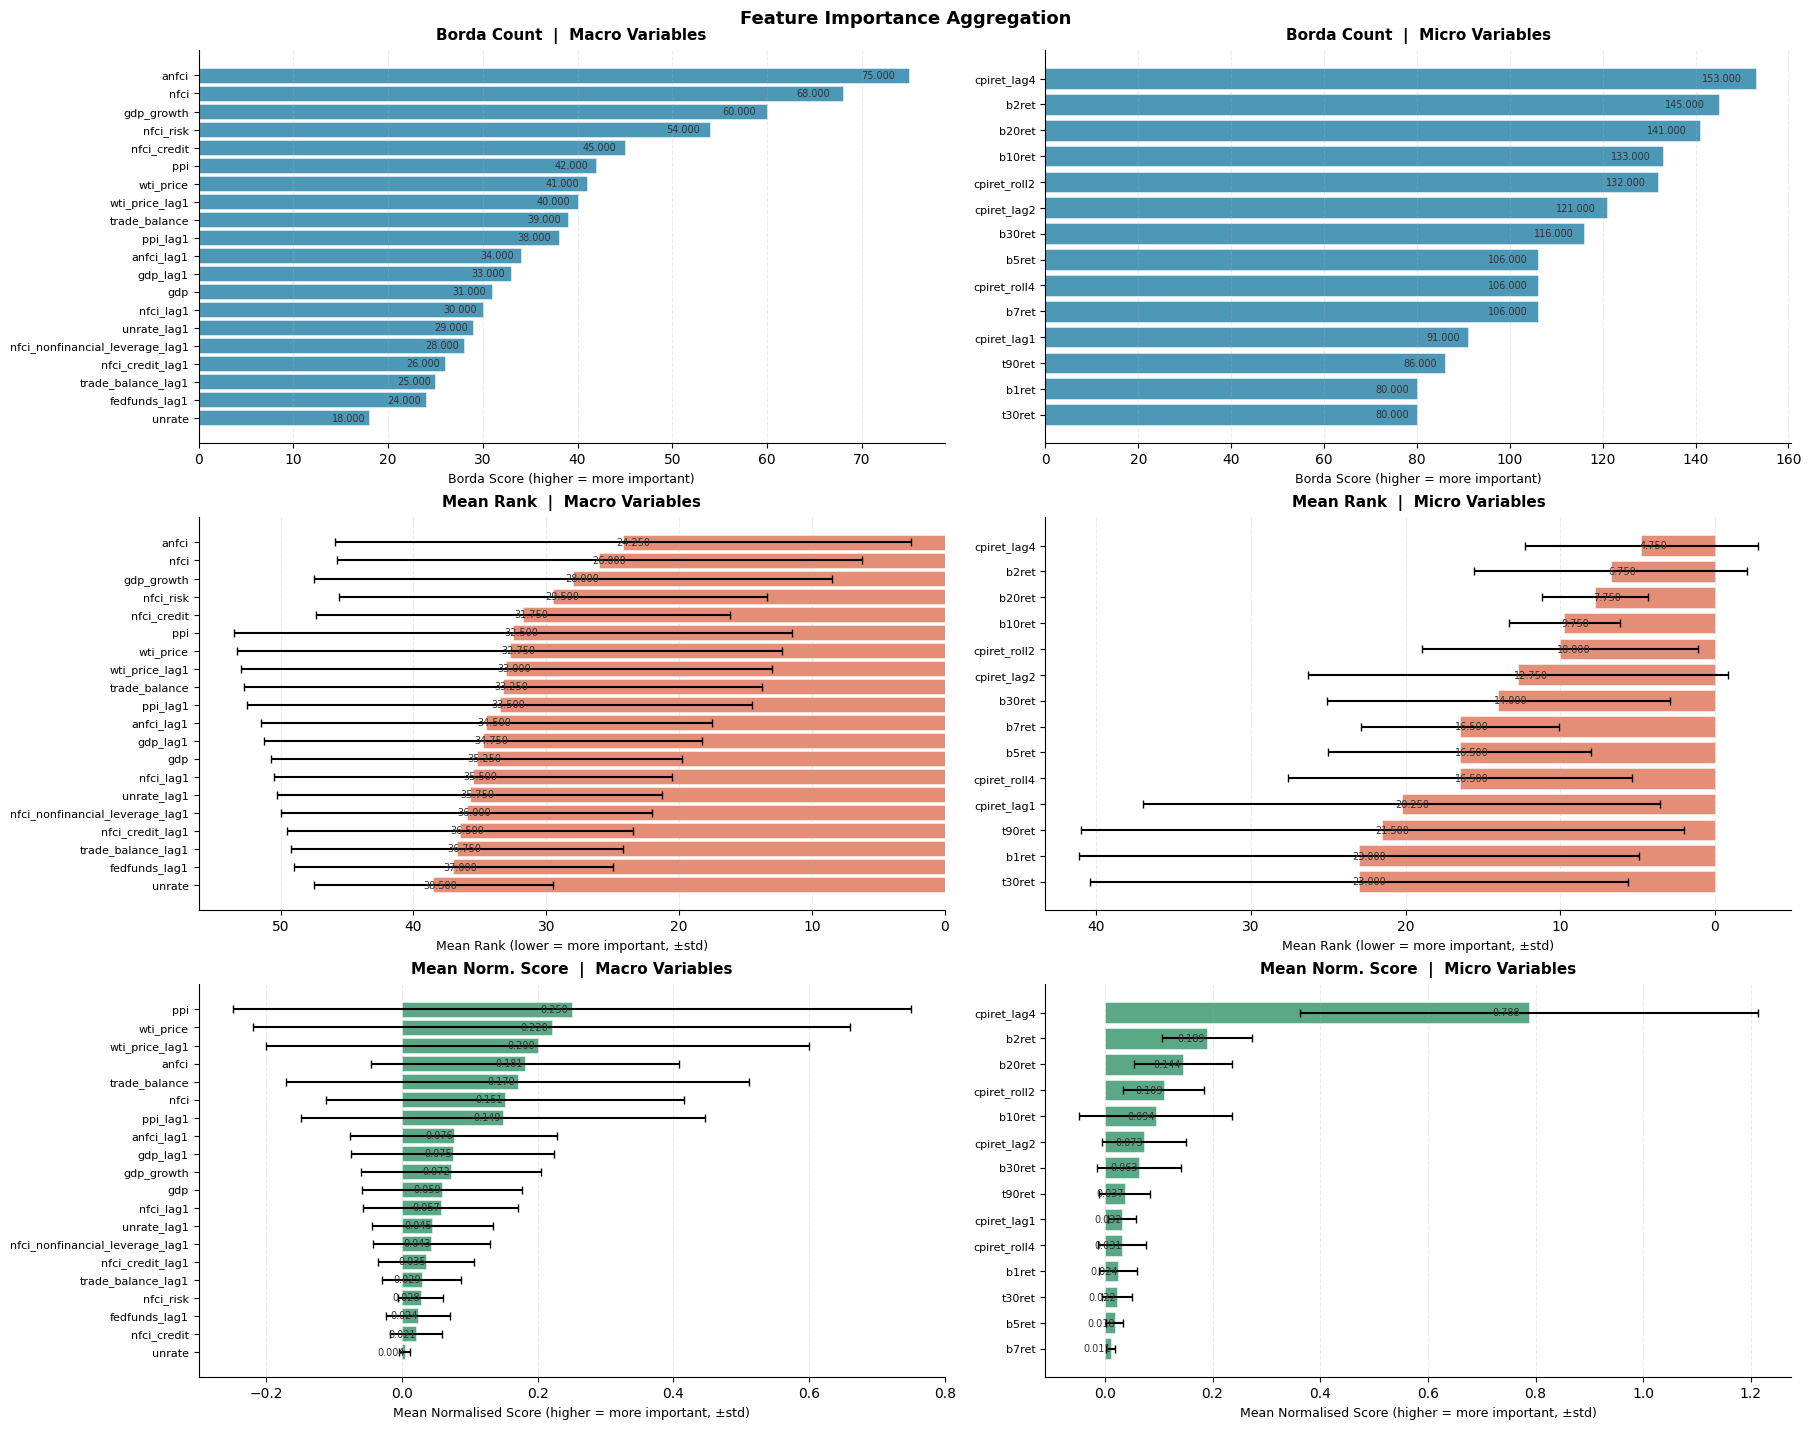


MODEL AGREEMENT — Top 10 features per model
  cpiret_lag4                    ███        3/4 (75%)  [micro]
  b2ret                          ███        3/4 (75%)  [micro]
  b20ret                         ███        3/4 (75%)  [micro]
  cpiret_lag2                    ███        3/4 (75%)  [micro]
  cpiret_roll2                   ███        3/4 (75%)  [micro]
  b10ret                         ███        3/4 (75%)  [micro]
  b30ret                         ██         2/4 (50%)  [micro]
  t90ret                         ██         2/4 (50%)  [micro]
  t30ret                         ██         2/4 (50%)  [micro]
  anfci                          ██         2/4 (50%)  [macro]
  b5ret                          █          1/4 (25%)  [micro]
  gdp_growth                     █          1/4 (25%)  [macro]
  cpiret_roll4                   █          1/4 (25%)  [micro]
  nfci_credit                    █          1/4 (25%)  [macro]
  ppi                            █          1/4 (25%)  [macro]
  wti_pric

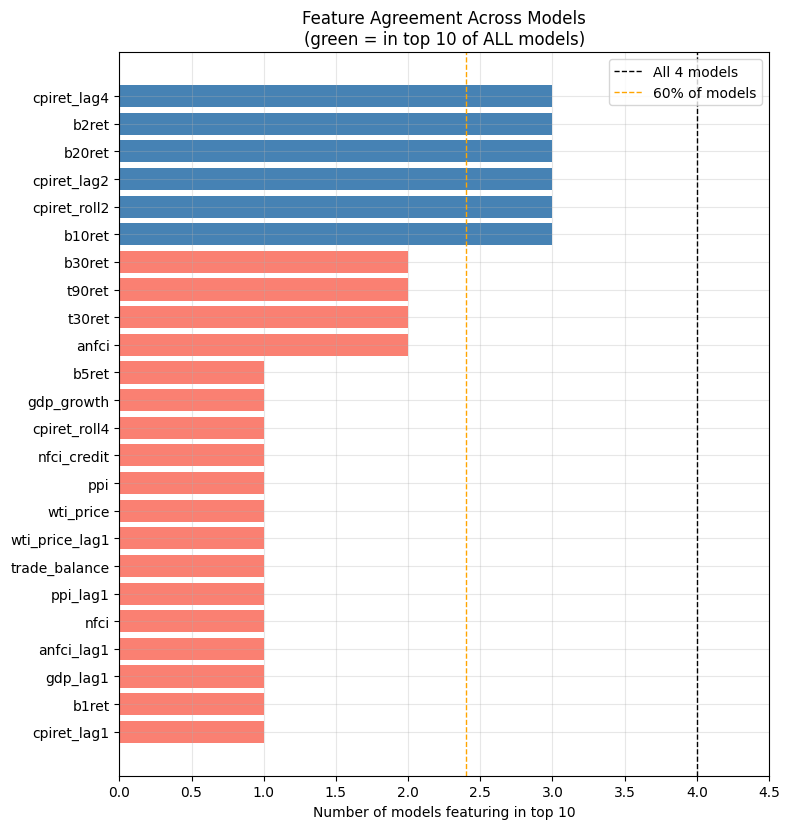

In [ ]:
importance_results = {
    'XGB':      xgb_fi_shap,
    'GB':       gb_fi_shap,
    'bayes':    bayes_fi_shap,
    'catboost': catboost_fi_shap,
}

aggregated = aggregate_feature_importance(
    importance_results,
    top_n=20
)

vote_df = plot_model_agreement(importance_results, top_n=10)